# Take-Home Technical Exercise
### Research Scientist, Machine Learning (Risk Modelling and Decision Systems)

**What to submit:** A single Jupyter notebook (or a short report plus code) that we can read top-to-bottom, with your reasoning written inline. Reproducibility matters — we should be able to re-run it. Any language is acceptable; Python is preferred.

**A note on tools:** You may use whatever libraries and, if you wish, AI assistants you would normally use — we care about your judgement, not whether you memorised an API. If you use an AI tool, we would appreciate a sentence on where it helped and where you overrode it, because knowing when not to trust a suggestion is part of the job.

---

## Context

This role is about estimating the **true, risk-adjusted value of a business deal** when the information needed to do so is sparse and unevenly recorded. To let you work on the flavour of that problem without any confidential data, we have created a small **synthetic dataset** of completed export orders. Each row is one order that shipped; some incurred a financial loss after the sale (a dispute, a return, a late or missed payment, extra freight cost), and most did not.

The dataset and its column descriptions are in the accompanying file `orders.csv` and `data_dictionary.md`. It is deliberately small and deliberately imperfect.

---

## Part 1: Understand the data

Explore the dataset and tell us what you find. We are specifically interested in whether you notice:

- how often losses actually occur, and how their sizes are distributed;
- any data-quality problems, missing fields, or fields that look unreliable;
- anything about how the data was generated that would affect how much you can trust it.

Write down what you observe, in plain language, as if briefing a colleague.

## Part 2: Model something useful

Build a model, or models, that would help the business decide which future orders are risky. You have latitude in exactly what you predict — that choice, and your justification for it, is part of what we are assessing. You might, for example, model the *probability* that an order incurs a loss, the *size* of the loss if one occurs, or an *expected loss* that combines both. Tell us why you framed it the way you did.

We are not looking for a high accuracy number. We are looking for:

- a modelling choice that fits the data you actually have, not the data you wish you had;
- sensible handling of the fact that losses are rare and vary a lot in size;
- an evaluation that measures something meaningful, and an honest read of how well it worked;
- clear acknowledgement of what your model cannot do or where it is likely to be unreliable.

If you try something and it does not work, keep it in and tell us why — that is useful signal, not a failure.

## Part 3: Judgement and communication (roughly 1 hour)

Answer these three questions in detail:

1. **Sparsity.** Suppose the single most expensive category of loss (say, a major customer default) has only happened five or six times in the whole dataset, but when it happens it dwarfs everything else. How would you approach estimating the risk of it, given you have almost no examples? What would you *not* do?

2. **Trust.** These orders were historically approved by human sales staff who decided which deals to pursue and at what price. Does that affect what your model can validly learn or claim from this data? If so, how, and what would you do about it?

3. **Decision.** Your model produces a risk estimate. The business wants to use it to decide which orders to prioritise. Would you use it to *drop* risky orders from consideration, or in some other way? Briefly justify your recommendation.

---

## What we are assessing

To be transparent, here is roughly how we read submissions. There are no hidden traps and no single "right" answer to Parts 2 or 3.

| Dimension | What a strong submission shows |
|---|---|
| **Problem framing** | Chooses a sensible target and objective, and explains why, rather than reflexively fitting a classifier. |
| **Reasoning under sparsity** | Recognises rare events and heavy tails as the central difficulty and responds to them thoughtfully. |
| **Statistical judgement** | Understands uncertainty; does not oversell a result; picks evaluation metrics that mean something. |
| **Honesty** | States limitations plainly; distinguishes what the data can and cannot support. |
| **Communication** | We can follow the reasoning end-to-end without reverse-engineering the code. |

---

## Practical details


- If anything is ambiguous, make a reasonable assumption, state it, and continue. Refrain from emailing us for clarification, as handling ambiguity is part of the exercise.
- Return your submission within **7 days** of receiving it.

We know a take-home is a real ask on your time, and we appreciate it. If you reach the interview stage, we will spend most of that conversation discussing the choices you made here, so there is no need to polish, as we want to see how you think.

# Data Dictionary — `orders.csv`

This is a **synthetic** dataset created for this exercise. It does not contain any real Teleshop data. It is designed to resemble the *shape* of the problem this role works on: completed export orders, a minority of which incurred a financial loss after the sale, recorded imperfectly.

Each row is one order that shipped.

| Column | Type | Description |
|---|---|---|
| `order_id` | integer | Unique identifier for the order. |
| `ship_date` | date | Date the order shipped. |
| `buyer_region` | category | Buyer's region. Occasionally missing. |
| `product_category` | category | One of `home_appliance`, `beauty`, `cleaning`, `pet_care`. |
| `order_value_usd` | float | Gross value of the order in USD. |
| `buyer_tenure_yrs` | float | How long this buyer has traded with the company, in years. |
| `new_buyer` | 0/1 | Flag: 1 if this is effectively a new buyer (short tenure). |
| `payment_terms_days` | integer | Credit terms granted: 0 (prepaid), 30, 60, or 90 days. |
| `route_risk_flag` | category | Internal shipping-route risk label: `low`, `medium`, `high`. |
| `rep_confidence_score` | float | A score (0–1) recorded by the sales representative at the time of the deal, reflecting their own confidence in the order. Its exact meaning is not formally documented. |
| `loss_recorded` | 0/1 | 1 if a financial loss has been recorded against this order. |
| `loss_type` | category | Type of loss if recorded: `freight_overrun`, `return`, `dispute`, `late_payment`, `default`, or `none`. |
| `loss_amount_usd` | float | Recorded size of the loss in USD. May be missing even when a loss is recorded (the figure was not always logged). |
| `days_to_loss_recorded` | float | Days between shipment and the loss being recorded. Blank if no loss recorded. |
| `notes` | text | Free-text note from the accounts or shipping team, where one exists. Frequently blank. Occasionally present on orders with no recorded loss. |

## Things worth knowing

- The data was assembled from internal records that were **not designed for analysis**. Some fields are more reliable than others.
- A recorded loss reflects what had been logged **as of the time the data was extracted**. Orders ship on different dates, so different orders have been "observed" for different lengths of time.
- Losses vary enormously in size depending on type.
- You are not expected to use every column. Part of the exercise is deciding what to rely on.

If something about the data seems off or inconvenient, that is not a mistake in the file — it is part of what we are asking you to navigate. Note it and proceed.


## 0. Importing Initial Libraries and Exporting Data

In [5]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [6]:
CSV_PATH = "../dataset/orders.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)
df.head()

,order_id,ship_date,buyer_region,product_category,order_value_usd,buyer_tenure_yrs,new_buyer,payment_terms_days,route_risk_flag,rep_confidence_score,loss_recorded,loss_type,loss_amount_usd,days_to_loss_recorded,notes
0,18,2025-01-17,EU-West,beauty,4279.91,5.2,0,30,medium,0.86,0,none,0.00,NaN,NaN
1,99,2025-05-26,EU-West,home_appliance,14589.12,10.7,0,0,medium,0.49,1,dispute,759.70,79.0,quality complaint raised
2,790,2024-01-10,EU-North,pet_care,3918.59,2.7,0,90,medium,0.32,1,return,907.74,29.0,NaN
3,631,2024-03-15,EU-South,home_appliance,12236.41,7.3,0,30,low,0.39,0,none,0.00,NaN,NaN
4,811,2025-04-14,EU-West,pet_care,5810.34,5.1,0,30,low,0.75,0,none,0.00,NaN,NaN


In [7]:
df.shape

(1400, 15)

Data looks good at the first glance.

#### Initial observations:

- There are 15 features
- 1400 rows

Now let's have a look at the features:

In [8]:
## Total feature
print(f"Total features: {df.shape[1]}")

## List feature names
print(f"Feature Names: {list(df.columns)}")

Total features: 15
Feature Names: ['order_id', 'ship_date', 'buyer_region', 'product_category', 'order_value_usd', 'buyer_tenure_yrs', 'new_buyer', 'payment_terms_days', 'route_risk_flag', 'rep_confidence_score', 'loss_recorded', 'loss_type', 'loss_amount_usd', 'days_to_loss_recorded', 'notes']


**These three features `loss_recorded`, `loss_type`, `loss_amount_usd` may be dealing with the sparsity.**

In [9]:
df.keys()

Index(['order_id', 'ship_date', 'buyer_region', 'product_category', 'order_value_usd', 'buyer_tenure_yrs', 'new_buyer', 'payment_terms_days',
       'route_risk_flag', 'rep_confidence_score', 'loss_recorded', 'loss_type', 'loss_amount_usd', 'days_to_loss_recorded', 'notes'],
      dtype='object')

**.keys()** here returns the same as an Index object containing the column labels

**let's check the `describe` method to begin with.**

In [10]:
print(df.describe())

        order_id  order_value_usd  buyer_tenure_yrs    new_buyer  payment_terms_days  rep_confidence_score  loss_recorded  loss_amount_usd  \
count  1400.0000      1400.000000       1400.000000  1400.000000         1400.000000           1400.000000    1400.000000      1362.000000   
mean    700.5000     12727.560014          4.056071     0.079286           37.478571              0.509550       0.150000       134.879244   
std     404.2895     10186.681439          2.793271     0.270281           28.334762              0.190956       0.357199       791.536390   
min       1.0000      1444.320000          0.000000     0.000000            0.000000              0.000000       0.000000         0.000000   
25%     350.7500      6198.502500          2.000000     0.000000           30.000000              0.390000       0.000000         0.000000   
50%     700.5000      9940.160000          3.400000     0.000000           30.000000              0.520000       0.000000         0.000000   
75%   

#### Some Observations:

- Average loss amount is USD 134.88 
- Max loss amount is USD 20811.84
- On an average, almost two months back a loss is recorded (59 days)
  
we are measuring the following 8 calculations for numerical features:
- **count**: Total number of non-missing (non-null) values.
- **mean**: The average value.
- **std**: Standard deviation (how spread out the data points are).
- **min**: The lowest value in the dataset for a feature.
- **25%**: The 25th percentile (the value below which 25% of the data falls).
- **50%**: The median (the middle value of the data).
- **75%**: The 75th percentile (the value below which 75% of the data falls).
- **max**: The highest value in the dataset.

**Let's have a look at the dataset again to check how much we can verify these numbers, just for an idea.**

In [11]:
df.head(10)

,order_id,ship_date,buyer_region,product_category,order_value_usd,buyer_tenure_yrs,new_buyer,payment_terms_days,route_risk_flag,rep_confidence_score,loss_recorded,loss_type,loss_amount_usd,days_to_loss_recorded,notes
0,18,2025-01-17,EU-West,beauty,4279.91,5.2,0,30,medium,0.86,0,none,0.00,NaN,NaN
1,99,2025-05-26,EU-West,home_appliance,14589.12,10.7,0,0,medium,0.49,1,dispute,759.70,79.0,quality complaint raised
2,790,2024-01-10,EU-North,pet_care,3918.59,2.7,0,90,medium,0.32,1,return,907.74,29.0,NaN
3,631,2024-03-15,EU-South,home_appliance,12236.41,7.3,0,30,low,0.39,0,none,0.00,NaN,NaN
4,811,2025-04-14,EU-West,pet_care,5810.34,5.1,0,30,low,0.75,0,none,0.00,NaN,NaN
5,102,2024-03-04,EU-North,pet_care,10433.53,3.7,0,30,low,0.51,1,dispute,4822.01,33.0,buyer disputes invoice
6,903,2025-05-16,EU-West,beauty,3330.62,3.1,0,60,low,0.54,0,none,0.00,NaN,NaN
7,1251,2024-11-18,EU-West,pet_care,22871.33,3.5,0,0,low,0.87,0,none,0.00,NaN,NaN
8,722,2024-05-20,EU-East,home_appliance,16992.85,1.7,0,90,low,0.51,0,none,0.00,NaN,NaN
9,446,2024-11-17,EU-North,cleaning,14697.64,2.4,0,60,low,0.44,0,none,0.00,NaN,NaN


A note worth observation that,
- average confidence score by a sales representative **at the time of the deal is around 50%**, depicted on the `rep_confidence_score` feature. It reflects the rep's own confidence in the order. Event though, its exact meaning is not formally documented.
- a loss recorded in binary Yes/ No (0,1) in `loss_recorded` has corresponding `loss_type`,	`loss_amount_usd`, `days_to_loss_recorded` and `notes`. These are important observations as **these features are highly possitively correlated** with target feature computation. We will understand this in detail in Feature Engineering and Selection section.

## 1. Exploratory Data Analysis

In this step, we typically work with 4 distinct tasks (A,B,C,D below) **to find the flaws in data** consuming almost 70-75% of the data tasks. The deeper the better.

Let's start with a **crucial check:**
- **We have to deal with these features of various types while analyzing the entire dataset.**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1400 non-null   int64  
 1   ship_date              1400 non-null   object 
 2   buyer_region           1327 non-null   object 
 3   product_category       1400 non-null   object 
 4   order_value_usd        1400 non-null   float64
 5   buyer_tenure_yrs       1400 non-null   float64
 6   new_buyer              1400 non-null   int64  
 7   payment_terms_days     1400 non-null   int64  
 8   route_risk_flag        1400 non-null   object 
 9   rep_confidence_score   1400 non-null   float64
 10  loss_recorded          1400 non-null   int64  
 11  loss_type              1400 non-null   object 
 12  loss_amount_usd        1362 non-null   float64
 13  days_to_loss_recorded  210 non-null    float64
 14  notes                  159 non-null    object 
dtypes: f

#### Observations:
- `ship_date`, `buyer_region` (where the customer is located), `product_category`, `route_risk_flag` and `loss_type` along with `notes` (available with loss deals only)- **Categorical Features**
- rest are numerical features


we will deal with these in corresponding sub-sections below

In [13]:
print(df.describe)

<bound method NDFrame.describe of       order_id   ship_date buyer_region product_category  order_value_usd  buyer_tenure_yrs  new_buyer  payment_terms_days route_risk_flag  \
0           18  2025-01-17      EU-West           beauty          4279.91               5.2          0                  30          medium   
1           99  2025-05-26      EU-West   home_appliance         14589.12              10.7          0                   0          medium   
2          790  2024-01-10     EU-North         pet_care          3918.59               2.7          0                  90          medium   
3          631  2024-03-15     EU-South   home_appliance         12236.41               7.3          0                  30             low   
4          811  2025-04-14      EU-West         pet_care          5810.34               5.1          0                  30             low   
...        ...         ...          ...              ...              ...               ...        ...            

#### Summarizing the stats of the data

In [14]:
print(df.describe())

        order_id  order_value_usd  buyer_tenure_yrs    new_buyer  payment_terms_days  rep_confidence_score  loss_recorded  loss_amount_usd  \
count  1400.0000      1400.000000       1400.000000  1400.000000         1400.000000           1400.000000    1400.000000      1362.000000   
mean    700.5000     12727.560014          4.056071     0.079286           37.478571              0.509550       0.150000       134.879244   
std     404.2895     10186.681439          2.793271     0.270281           28.334762              0.190956       0.357199       791.536390   
min       1.0000      1444.320000          0.000000     0.000000            0.000000              0.000000       0.000000         0.000000   
25%     350.7500      6198.502500          2.000000     0.000000           30.000000              0.390000       0.000000         0.000000   
50%     700.5000      9940.160000          3.400000     0.000000           30.000000              0.520000       0.000000         0.000000   
75%   

### A. EDA- Missing Value Analysis

In [15]:
df.isnull()

,order_id,ship_date,buyer_region,product_category,order_value_usd,buyer_tenure_yrs,new_buyer,payment_terms_days,route_risk_flag,rep_confidence_score,loss_recorded,loss_type,loss_amount_usd,days_to_loss_recorded,notes
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
1396,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
1397,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
1398,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True


In [16]:
total_nulls = df.isnull().sum().sum()
print(total_nulls)

2542


In [17]:
print(df.isnull().sum())

order_id                    0
ship_date                   0
buyer_region               73
product_category            0
order_value_usd             0
buyer_tenure_yrs            0
new_buyer                   0
payment_terms_days          0
route_risk_flag             0
rep_confidence_score        0
loss_recorded               0
loss_type                   0
loss_amount_usd            38
days_to_loss_recorded    1190
notes                    1241
dtype: int64


**Four features** contain missing values.

**Let's calculate the proportion and intensity of Null Values that might impact the analysis.**

In [18]:
null_pct = df['loss_amount_usd'].isnull().mean() * 100
print(f"{null_pct}%")

null_count = df['loss_amount_usd'].isnull().sum()
print(null_count)

2.7142857142857144%
38


In [19]:
null_pct = df['days_to_loss_recorded'].isnull().mean() * 100
print(f"{null_pct}%")

null_count = df['days_to_loss_recorded'].isnull().sum()
print(null_count)

85.0%
1190


#### Observation:
- while close to 3% of the deals only, that actually encountered loss `loss_amount_usd` with respect to 85% of deals having no `days_to_loss_recorded`.

In [16]:
null_pct = df['notes'].isnull().mean() * 100
print(f"{null_pct}%")

null_count = df['notes'].isnull().sum()
print(null_count)

88.64285714285714%
1241


#### Derived Observation Metric:
- 85% of deals having no `days_to_loss_recorded` against 88% with no `notes`.
- only 2.7% of deals have notes against deals encountering a `loss`

In [20]:
missing = df.isna().sum().to_frame('n_missing')
missing['pct_missing'] = (missing['n_missing'] / len(df) * 100).round(1)
missing = missing[missing.n_missing > 0]
missing

,n_missing,pct_missing
buyer_region,73,5.2
loss_amount_usd,38,2.7
days_to_loss_recorded,1190,85.0
notes,1241,88.6


**Let's take a look at these statistics graphically:**

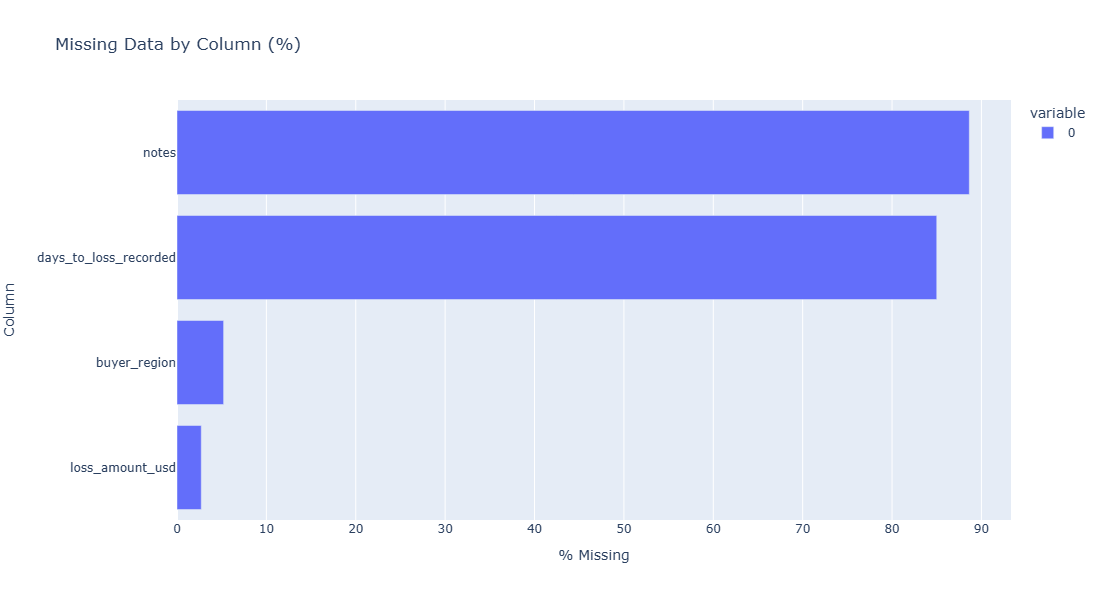

In [21]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
fig = px.bar(
    missing,
    orientation='h',
    labels={'value': '% Missing', 'index': 'Column'},
    title='Missing Data by Column (%)'
)
fig.update_layout(height=600, yaxis={'categoryorder': 'total ascending'})
fig.show()

#### Observations: Dealing with Missing or Null values

Four feature have missing values, but among them three are for very different reasons, and they need very different treatment:

| Feature | Missing Count | % missing | Why it's missing | Risk | Is this a data-quality problem? |
|---|---|---|---|---|---|
| `buyer_region` | 73 | ~5% | Looks like genuine data-entry gaps | Low-risk, randomly missing categorical feature | Yes — needs imputation / an explicit "Unknown" bucket |
| `loss_amount_usd` | 38 | 2.7% overall, but **~18% of orders where a loss *was* recorded** | "the figure was not always logged" (per the data dictionary) — an operational logging gap, not an absence of loss | High-risk target column leak (**sparsity**) | Yes, and it's the important one: we know a loss happened but not how big |
| `days_to_loss_recorded` | 1190 | ~85% | Structurally blank whenever `loss_recorded == 0` | Data is missing because no loss occurred, no-risk | No — this is expected, not missing data. Let's keep as-is for Phase 1; will handle structurally for Phase 2 |
| `notes` | 1241 | ~89% | Free text is only written when someone bothered to | May break standard algorithms, low-risk | No, but its *presence* is itself a weak signal, may be converted to a binary flag (has_notes) |


**Key considerations while using Null or Missing imputations:**
- Data and further computation should not be manipulated
- The one that matters most for modelling is `loss_amount_usd` missing conditional on `loss_recorded == 1`. Imputing this naively (e.g. with 0) would silently understate risk.
- Hence, near precision approach should be used
- Additionally, we will verify how much `buyer_region` feature correlates with these deciding features Feature Engineering section.

In [22]:
# loss_amount_usd missingness is conditional on loss_recorded, not random
print('loss_amount_usd missing | loss_recorded==1:',
      df.loc[df.loss_recorded==1, 'loss_amount_usd'].isna().mean().round(3), '(n =', (df.loss_recorded==1).sum(), ')')
print('loss_amount_usd missing | loss_recorded==0:',
      df.loc[df.loss_recorded==0, 'loss_amount_usd'].isna().mean().round(3))

# is loss_amount missingness related to loss_type? (informative missingness would matter for imputation)
pd.crosstab(df.loc[df.loss_recorded==1,'loss_type'], df.loc[df.loss_recorded==1,'loss_amount_usd'].isna(),
            rownames=['loss_type'], colnames=['amount_missing'])

loss_amount_usd missing | loss_recorded==1: 0.181 (n = 210 )
loss_amount_usd missing | loss_recorded==0: 0.0


amount_missing,False,True
loss_type,,
default,5,7
dispute,43,8
freight_overrun,59,10
late_payment,28,5
return,37,8


#### Observations:
- `loss_amount_usd` missingness is conditional on `loss_recorded`, not random
- `loss_amount_usd` missingness is not related to `loss_type`.

  **This informative missingness would matter for imputation**. `loss_amount_usd` is missing across every loss type roughly in proportion to how common that type is — nothing jumps out as systematically under-logged, so this looks like plain operational sloppiness rather than a pattern tied to severity. That makes conditional imputation a reasonable choice rather than a source of new bias.

### B. EDA- Duplicate Value Analysis


**Check for duplicates and identifiers:**

In [23]:
print('Duplicate order_id:', df.order_id.duplicated().sum())
print('Fully duplicate rows:', df.duplicated().sum())
print('order_id range:', df.order_id.min(), '-', df.order_id.max(), '| unique:', df.order_id.nunique(), '/ n rows:', len(df))

Duplicate order_id: 0
Fully duplicate rows: 0
order_id range: 1 - 1400 | unique: 1400 / n rows: 1400


Let's verify these individually- for rows and total.

In [24]:
total_duplicates = df.duplicated().sum()
print(total_duplicates)

0


In [25]:
## actual duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [order_id, ship_date, buyer_region, product_category, order_value_usd, buyer_tenure_yrs, new_buyer, payment_terms_days, route_risk_flag, rep_confidence_score, loss_recorded, loss_type, loss_amount_usd, days_to_loss_recorded, notes]
Index: []


#### Observations:
1. No duplicate **rows** is found. 
2. Also, no duplicate **`order_id`s**.

    However, `order_id` is a clean primary key and we will drop it from modelling features (it carries no signal and risks the model latching onto row order as a proxy for time).

   No further action is required, good to proceed as of now.

### C. EDA- Categorical Feature Analysis

As figured out above, the dataset contains the following categorical features:

- `ship_date`
- `buyer_region` - required feature
- `product_category` - required feature
- `route_risk_flag` - required feature
- `loss_type`
- `notes`

Binary or ordinal - categorical features:
- `payment_terms_days` - required feature
- `new_buyer` - required feature

This step is crucial because we will identify which categorical features are most aligned with the target feature and if they need to be scaled for computation (required feature)

In [26]:
print (df['buyer_region'].unique())

print (df['product_category'].unique())

print (df['route_risk_flag'].unique())

print (df['loss_type'].unique())

print (df['notes'].unique())

print (df['payment_terms_days'].unique())

print (df['new_buyer'].unique())

['EU-West' 'EU-North' 'EU-South' 'EU-East' nan]
['beauty' 'home_appliance' 'pet_care' 'cleaning']
['medium' 'low' 'high']
['none' 'dispute' 'return' 'freight_overrun' 'late_payment' 'default']
[nan 'quality complaint raised' 'buyer disputes invoice'
 'paid 40 days late' 'extra freight billed' 'container reweigh cost'
 'buyer queried ETA' 'goods sent back' 'chargeback pending'
 'account written off' 'buyer returned partial shipment'
 'minor delay, no cost' 'QC reject on arrival' 'carrier surcharge applied'
 'non-payment - escalated' 'remittance overdue' 'payment delayed'
 'buyer did not pay']
[30  0 90 60]
[0 1]


#### Observation and Decision:
- we can label the `nan` category under `buyer_region` feature with `unknown`.
- quantify the categories under `route_risk_flag` and `loss_type` as 0,1,2, etc. for computation.

Let's have a look at **how the categories are spread over** under each of the features:

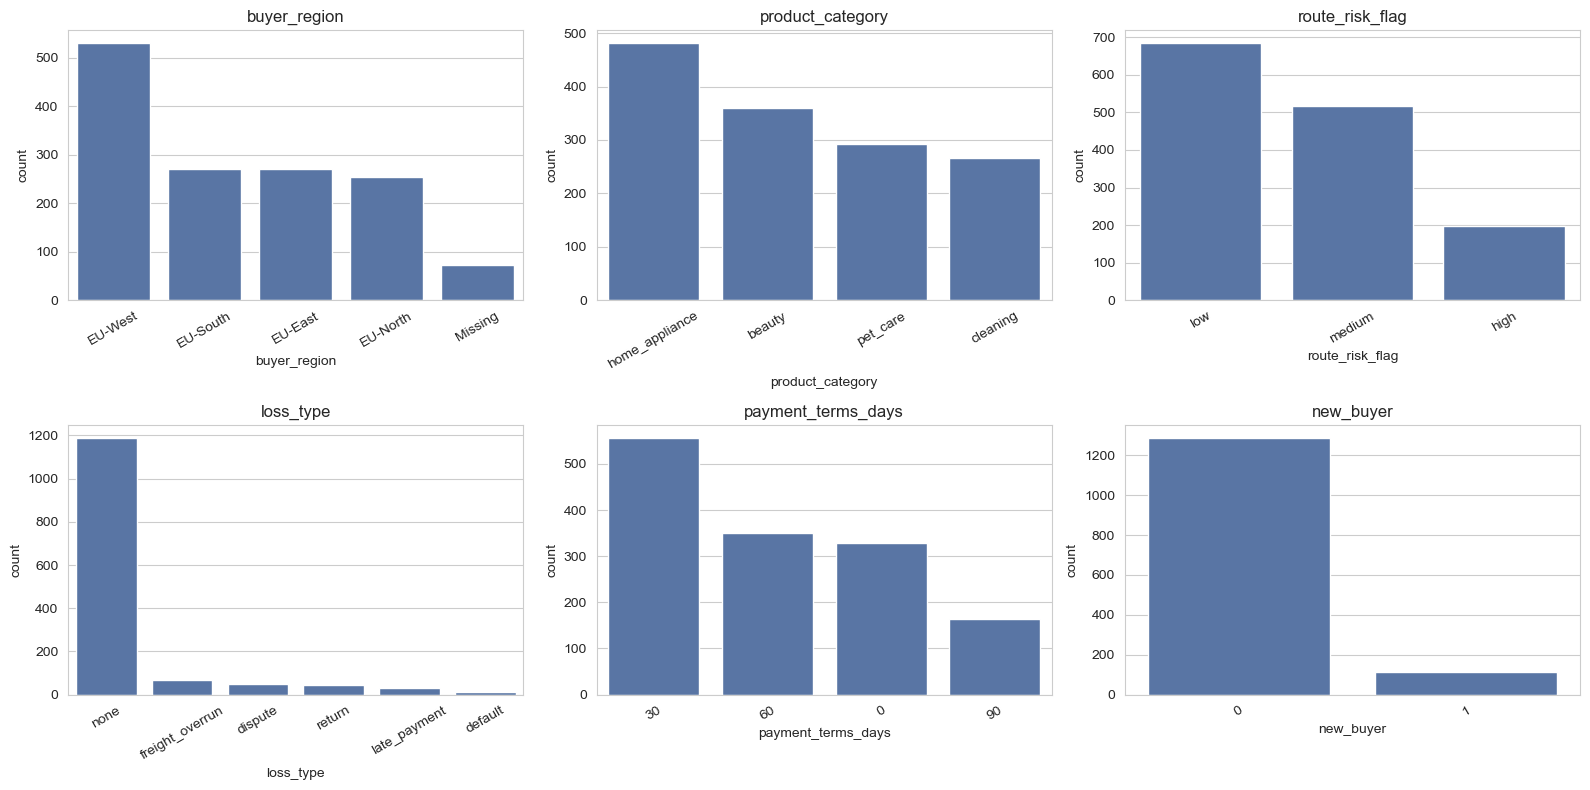

In [27]:
cat_cols = ['buyer_region', 'product_category', 'route_risk_flag', 'loss_type', 'payment_terms_days', 'new_buyer']
plot_df = df.copy()
plot_df['buyer_region'] = plot_df['buyer_region'].fillna('Missing')  # plotting only -- real imputation happens later

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.flat, cat_cols):
    order = plot_df[c].astype(str).value_counts().index
    sns.countplot(data=plot_df.astype({c: str}), x=c, order=order, ax=ax, color='#4C72B0')
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

`buyer_region` has a missing bar showing NaN values. As we figured out in 1.A, it encompasses **roughly around 5% of total deals (73)**.
Let's proceed to see the actual numbers below:

In [28]:
for c in ['buyer_region', 'product_category', 'route_risk_flag', 'payment_terms_days', 'new_buyer']:
    print(f'--- {c} ---')
    print(df[c].value_counts(dropna=False))
    print()

--- buyer_region ---
EU-West     530
EU-South    271
EU-East     271
EU-North    255
NaN          73
Name: buyer_region, dtype: int64

--- product_category ---
home_appliance    481
beauty            359
pet_care          293
cleaning          267
Name: product_category, dtype: int64

--- route_risk_flag ---
low       684
medium    517
high      199
Name: route_risk_flag, dtype: int64

--- payment_terms_days ---
30    557
60    350
0     329
90    164
Name: payment_terms_days, dtype: int64

--- new_buyer ---
0    1289
1     111
Name: new_buyer, dtype: int64



**Observations**
- `buyer_region` has 4 levels (EU-West is the largest) plus ~5% missing — no single region dominates so badly that region is useless, but sample sizes per region are modest once you slice further.
- `product_category` is reasonably balanced across 4 categories (`home_appliance` largest).
- `route_risk_flag` (`low`/`medium`/`high`) is ordinal in spirit even though stored as text — worth encoding as ordinal, not one-hot, so the model can exploit the ordering.
- `payment_terms_days` only takes 4 values (0/30/60/90) — effectively categorical/ordinal, not continuous. Longer terms plausibly increase risk (more time for something to go wrong before payment, more exposure).
- `new_buyer` is a **derived** flag ("short tenure") — check consistency against `buyer_tenure_yrs` below, since a flag built from a continuous field is a place synthetic data generation can be inconsistent.


### C. 1. Feature Selection: `new_buyer` & `buyer_tenure_yrs`
Let's do a sanity check if `new_buyer` is consistent with `buyer_tenure_yrs`:

In [29]:
print(df.groupby('new_buyer')['buyer_tenure_yrs'].describe()[['count','mean','min','50%','max']])
# find any contradictions: new_buyer==1 but long tenure, or new_buyer==0 but ~0 tenure
print()
print('new_buyer=1 but tenure > 2yrs:', ((df.new_buyer==1) & (df.buyer_tenure_yrs>2)).sum())
print('new_buyer=0 but tenure < 0.5yrs:', ((df.new_buyer==0) & (df.buyer_tenure_yrs<0.5)).sum())

            count      mean  min  50%   max
new_buyer                                  
0          1289.0  4.350892  1.0  3.7  20.9
1           111.0  0.632432  0.0  0.7   0.9

new_buyer=1 but tenure > 2yrs: 0
new_buyer=0 but tenure < 0.5yrs: 0


#### Observation and Decision 

- It is seen that, `new_buyer` is a clean, consistent derivation of `buyer_tenure_yrs` (no contradictions) — the two are collinear, 

- Let's keep `buyer_tenure_yrs` (more information) and drop `new_buyer` as a redundant duplicate feature rather than feeding the model the same information twice. It's a great catch in Feature Engineering and Selection.


### C. 2. Feature Selection: `loss_type` and `notes`
This is a next softer signal hiding in the data

In [30]:
print(df.loss_type.value_counts())
print()
# notes present when loss_recorded == 0 -- these are cases someone bothered to annotate even though
# no financial loss was formally recorded. Could be near-misses / weakly-labelled risk.
near_miss = df[(df.notes.notna()) & (df.loss_recorded==0)]
print(f'Orders with a note but NO recorded loss: {len(near_miss)}')
near_miss['notes'].value_counts()

none               1190
freight_overrun      69
dispute              51
return               45
late_payment         33
default              12
Name: loss_type, dtype: int64

Orders with a note but NO recorded loss: 20


buyer queried ETA       12
minor delay, no cost     8
Name: notes, dtype: int64

#### Observations:
- These 20 **"note but no loss"** rows (e.g. *"buyer queried ETA"*, *"minor delay, no cost"*) are a good example of **weak, informal signal**. We want to surface if: someone on the accounts/shipping team flagged something noteworthy, but it never became a formal `loss_recorded == 1`. They shouldn't be relabelled as losses (that would be inventing ground truth), but they're exactly the kind of case that belongs in the expert-validation queue, rather than being silently treated as clean negatives.

- **notes present** when `loss_recorded == 0` -- these are cases someone bothered to annotate even though
- no financial loss was formally recorded. Could be near-misses / weakly-labelled risk.

### D. EDA- Numerical Feature Analysis

Let's have a look at the features first using `df.describe()` method:

In [31]:
num_cols = ['order_value_usd', 'buyer_tenure_yrs', 'payment_terms_days', 'rep_confidence_score']
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
order_value_usd,1400.0,12727.560014,10186.681439,1444.32,6198.5025,9940.16,15921.80,85987.61
buyer_tenure_yrs,1400.0,4.056071,2.793271,0.00,2.0000,3.40,5.50,20.90
payment_terms_days,1400.0,37.478571,28.334762,0.00,30.0000,30.00,60.00,90.00
rep_confidence_score,1400.0,0.509550,0.190956,0.00,0.3900,0.52,0.65,1.00


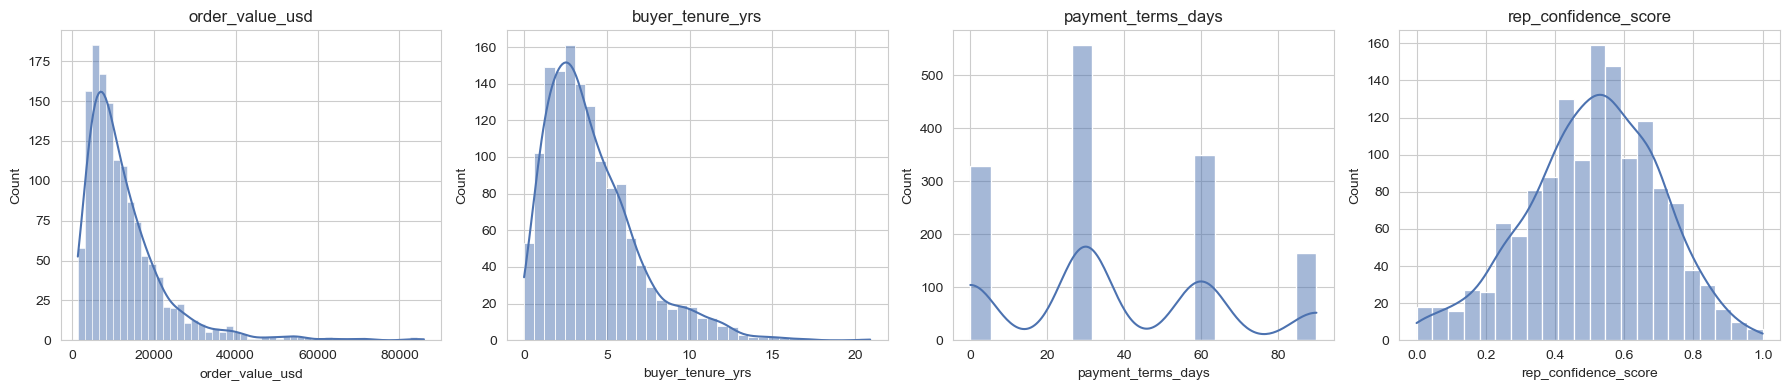

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(c)
plt.tight_layout()
plt.show()

#### Major Observations:
- `order_value_usd` is right-skewed (typical of transaction values) — no obvious outlier truncation, plausible range.
- `buyer_tenure_yrs` right-skewed with a floor at 0 (brand-new buyers) — consistent with `new_buyer`.
- `payment_terms_days` is really 4 discrete buckets, confirmed above.
- `rep_confidence_score` looks close to a smooth 0–1 normal distribution

#### Issue:
The data dictionary mentions, `rep_confidence_score`'s *meaning* is undocumented, which is a genuine trust issue, not just a data-quality one.

To get some idea, let's **check if higher "confidence" actually track with fewer losses**:

In [33]:
print(df.groupby('loss_recorded')['rep_confidence_score'].describe()[['count','mean','std','50%']])

                count      mean       std   50%
loss_recorded                                  
0              1190.0  0.518076  0.188045  0.53
1               210.0  0.461238  0.200391  0.49


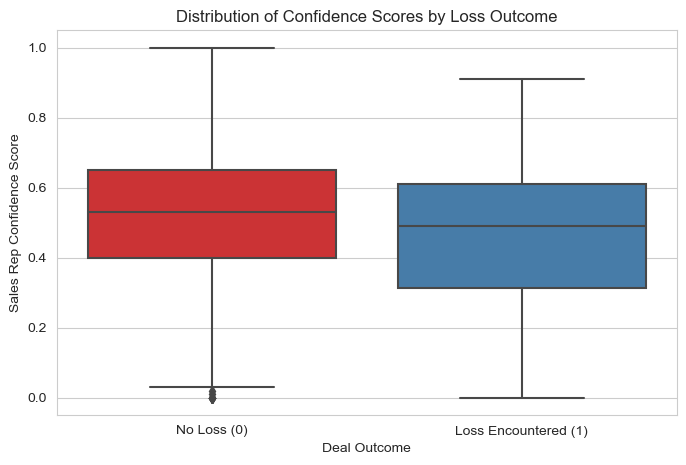

In [34]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='loss_recorded', y='rep_confidence_score', palette="Set1")

plt.xticks(ticks=[0, 1], labels=["No Loss (0)", "Loss Encountered (1)"])
plt.xlabel("Deal Outcome")
plt.ylabel("Sales Rep Confidence Score")
plt.title("Distribution of Confidence Scores by Loss Outcome")
plt.show()

#### Observations:
- `rep_confidence_score` is **barely** different between orders that did and didn't lose money (means ~0.52 vs ~0.46) — a small, plausible-direction gap, but weak. Since the field's exact meaning is undocumented, we treat it as a *candidate* feature to test rather than a trusted risk signal.

- we may need to flag this in model building, a human-recorded "confidence" field deserves scrutiny before being relied on operationally.


#### Let's check how often do losses occur and how their size are distributed:

In [35]:
loss_rate = df.loss_recorded.mean()
print(f'Overall loss rate: {loss_rate:.1%}  ({df.loss_recorded.sum()} of {len(df)} orders)')
print()
type_summary = df[df.loss_recorded==1].groupby('loss_type').agg(
    n=('order_id','count'),
    pct_of_losses=('order_id', lambda x: len(x)/df.loss_recorded.sum()),
    mean_amount=('loss_amount_usd','mean'),
    median_amount=('loss_amount_usd','median'),
    max_amount=('loss_amount_usd','max'),
    n_amount_missing=('loss_amount_usd', lambda x: x.isna().sum())
).round(1).sort_values('mean_amount')
type_summary

Overall loss rate: 15.0%  (210 of 1400 orders)



,n,pct_of_losses,mean_amount,median_amount,max_amount,n_amount_missing
loss_type,,,,,,
late_payment,33,0.2,258.1,232.5,821.0,5
freight_overrun,69,0.3,443.3,423.6,897.2,10
return,45,0.2,709.6,658.7,2459.7,8
dispute,51,0.2,1775.3,1348.2,5729.5,8
default,12,0.1,9546.2,5931.0,20811.8,7


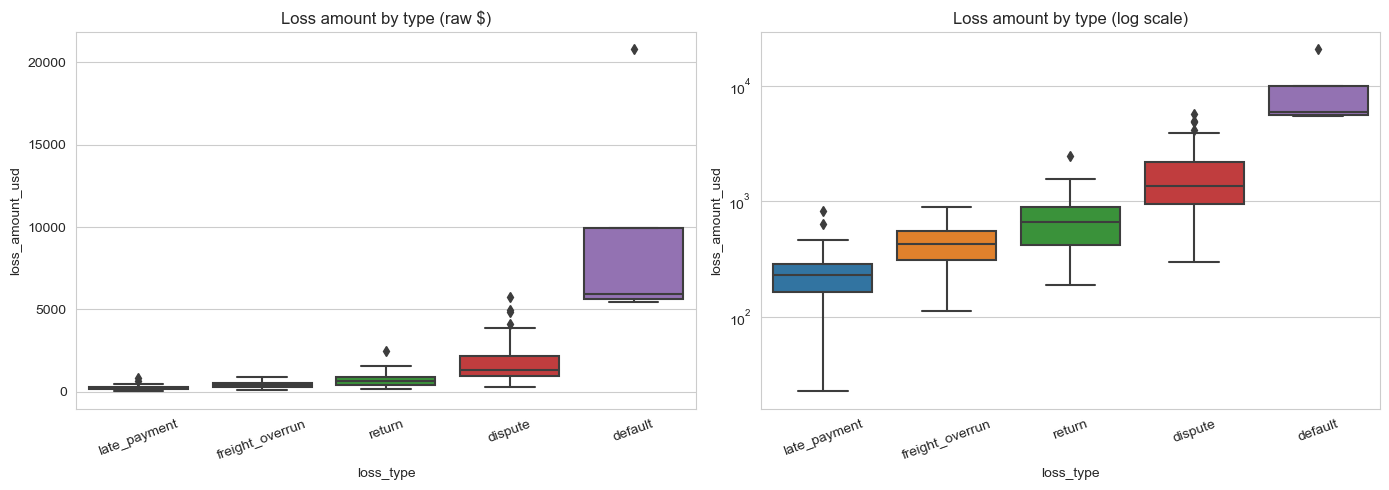

Share of total logged loss $ by type:
loss_type
dispute            41.6%
default            26.0%
return             14.3%
freight_overrun    14.2%
late_payment        3.9%
Name: loss_amount_usd, dtype: object


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_types = type_summary.index.tolist()
sns.boxplot(data=df[df.loss_recorded==1], x='loss_type', y='loss_amount_usd', order=order_types, ax=axes[0])
axes[0].set_title('Loss amount by type (raw \$)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df[df.loss_recorded==1], x='loss_type', y='loss_amount_usd', order=order_types, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Loss amount by type (log scale)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# contribution to total logged loss $ by type
total_loss = df.loc[df.loss_recorded==1, 'loss_amount_usd'].sum()
contrib = df[df.loss_recorded==1].groupby('loss_type')['loss_amount_usd'].sum().sort_values(ascending=False)
print('Share of total logged loss $ by type:')
print((contrib / total_loss * 100).round(1).astype(str) + '%')

#### Observations:
**This is the central fact of this dataset.** `default` occurs in only **12 of 1,400 orders (0.9%)** — and among *those*, only 5 have a logged dollar amount — yet it accounts for roughly a third of all logged loss dollars, with a max loss (~\$20.8k) that's an order of magnitude above the median `freight_overrun`. `dispute` is the next-heaviest tail. `freight_overrun` and `late_payment` are common but small.

In other words: **frequency and severity are almost inversely related across loss types.** A model (or a business process) that only optimises for "how often does this order lose money" will systematically under-weight the loss type that matters most in dollar terms. This shapes the whole modelling strategy in model development — especially under the section of `default`.

In [37]:
# loss amount distribution overall - classic heavy tail shape
losses_only = df.loc[(df.loss_recorded==1) & df.loss_amount_usd.notna(), 'loss_amount_usd']
print(losses_only.describe())
print()
print('Skewness:', losses_only.skew().round(2))
print('95th / 50th percentile ratio:', (losses_only.quantile(.95) / losses_only.quantile(.50)).round(1))
print('Top 5% of losses by $ account for:',
      f"{losses_only.sort_values(ascending=False).head(int(len(losses_only)*0.05)).sum() / losses_only.sum():.1%} of total logged loss $")

count      172.000000
mean      1068.055407
std       1996.015787
min         22.680000
25%        309.637500
50%        526.695000
75%        920.960000
max      20811.840000
Name: loss_amount_usd, dtype: float64

Skewness: 6.66
95th / 50th percentile ratio: 7.6
Top 5% of losses by $ account for: 34.4% of total logged loss $


#### Observations:
- Heavy right skew, and the top 5% of loss events by size account for a disproportionate share of total loss dollars. 

- This is the loss data: **frequency (rare) × severity (heavy-tailed)**


#### Let's check if the recent orders have faced a loss yet or haven't had time to document a loss

In [38]:
df['ship_date'] = pd.to_datetime(df['ship_date'])
extract_date = df['ship_date'].max()   # best available proxy for when the data was pulled
print('Ship date range:', df.ship_date.min().date(), 'to', df.ship_date.max().date())
print('Assumed extraction date (max ship date):', extract_date.date())
print('Max days_to_loss_recorded observed:', df.days_to_loss_recorded.max())

df['days_observed'] = (extract_date - df['ship_date']).dt.days
bins = [-1, 30, 60, 90, 120, 164, 100000]
labels = ['<30d', '30-60d', '60-90d', '90-120d', '120-164d', '164d+']
df['observation_window'] = pd.cut(df['days_observed'], bins=bins, labels=labels)

df.groupby('observation_window')['loss_recorded'].agg(['mean', 'count'])

Ship date range: 2024-01-01 to 2025-06-23
Assumed extraction date (max ship date): 2025-06-23
Max days_to_loss_recorded observed: 164.0


,mean,count
observation_window,,
<30d,0.235294,85
30-60d,0.090909,66
60-90d,0.136364,66
90-120d,0.119403,67
120-164d,0.121951,123
164d+,0.153072,993


#### Observations:
- Losses take up to **164 days** to get recorded after shipment.
- Orders shipped very recently (small `days_observed`) simply haven't had the full window to reveal a loss yet — this is right-censoring, not a genuine drop in risk for recent orders.
- The pattern here is noisy (small buckets) rather than a clean monotonic ramp, but the risk is real and matters more the closer an order's ship date is to the extraction date.
- **Practical implication:** the ~120 most-recently-shipped orders in this dataset are not safe to treat as confirmed "no loss" examples; we flag this as a source of label noise rather than silently accepting `loss_recorded == 0` at face value for them.


## 2. Feature Engineering
In this step,
- We typically clean, format, mitigate, and compensate the gaps that were identified in the EDA section.
- Out of many options and alternatives, I pick the best and most suitable solution for an application through rigorous R&D, personal experience, and study - all that should support the application we are going to build.
- **Tools:** Google Search, YouTube, AI assistants help in this section.

### 2.1 Filling Missing Values

How I handle missing values depends entirely on what the missing data actually means for each specific column.
As analysed and decided in the **1.A EDA - Missing Value Analysis** section, we will proceed *imputing* the NaN `buyer_region` entries with **"Unknown"** label.

In [39]:
df_clean = df.copy()

# buyer_region: genuine gap -> explicit "Unknown" category (never impute a region we don't know)
df_clean['buyer_region'] = df_clean['buyer_region'].fillna('Unknown')

`loss_amount_usd`is missing ONLY when loss_recorded==1 (logging gap). 

**Two-part fix:**
- 1) add a flag so the model can tell "amount was reported" from "amount was imputed"
- 2) impute using the median amount *for that loss_type* (severity is type-dependent, so a global
    - median would blend cheap freight overruns with expensive defaults and bias both)

In [40]:
df_clean['loss_amount_reported'] = (~((df_clean.loss_recorded==1) & df_clean.loss_amount_usd.isna())).astype(int)

type_medians = df_clean[df_clean.loss_recorded==1].groupby('loss_type')['loss_amount_usd'].median()
print('Median loss amount by type (used for conditional imputation):')
print(type_medians)

def impute_amount(row):
    if row['loss_recorded'] == 1 and pd.isna(row['loss_amount_usd']):
        return type_medians.get(row['loss_type'], np.nan)
    return row['loss_amount_usd']

df_clean['loss_amount_usd_imputed'] = df_clean.apply(impute_amount, axis=1)
df_clean['loss_amount_usd_imputed'] = df_clean['loss_amount_usd_imputed'].fillna(0)  # loss_recorded==0 -> 0

# days_to_loss_recorded: structurally blank when no loss. Leave as NaN (do NOT impute with 0 -- that
# would falsely claim "loss recorded on day 0" for orders with no loss at all).
print()

Median loss amount by type (used for conditional imputation):
loss_type
default            5930.99
dispute            1348.18
freight_overrun     423.64
late_payment        232.46
return              658.67
Name: loss_amount_usd, dtype: float64



In [41]:
print('Remaining missing values:')
print(df_clean[['buyer_region','loss_amount_usd_imputed']].isna().sum())

Remaining missing values:
buyer_region               0
loss_amount_usd_imputed    0
dtype: int64


**Key Takeaways: What led me adapt this approach**
In section 1.A while I found the missing values under `loss_amount_usd` feature occuring a substantial amount of times impacting the result - I had two options- to *drop* the rows and to *impute*. 

**Why not just drop the 38 rows with missing `loss_amount_usd`:** They're disproportionately valuable — they're *known* losses, just with an unlogged size — so dropping them would throw away exactly the label we most need (`loss_recorded==1`) in model development later, and quietly shrink an already-rare class. 

**How it was solved:** Conditional-median imputation (by `loss_type`) keeps them in the severity-regression training set while being explicit, via `loss_amount_reported`, about which values are real vs. filled in — so any regression model built downstream can see the difference. Model bookkeeping matters more than getting the imputed number exactly right: median-by-type is deliberately simple and directionally correct.


### Extended EDA- now let's have a look at the dataset and do some more analysis
This will help us identify if there is any hidden patterns or correlations in the dataset that may impact the solution.

In [42]:
df.head()

,order_id,ship_date,buyer_region,product_category,order_value_usd,buyer_tenure_yrs,new_buyer,payment_terms_days,route_risk_flag,rep_confidence_score,loss_recorded,loss_type,loss_amount_usd,days_to_loss_recorded,notes,days_observed,observation_window
0,18,2025-01-17,EU-West,beauty,4279.91,5.2,0,30,medium,0.86,0,none,0.00,NaN,NaN,157,120-164d
1,99,2025-05-26,EU-West,home_appliance,14589.12,10.7,0,0,medium,0.49,1,dispute,759.70,79.0,quality complaint raised,28,<30d
2,790,2024-01-10,EU-North,pet_care,3918.59,2.7,0,90,medium,0.32,1,return,907.74,29.0,NaN,530,164d+
3,631,2024-03-15,EU-South,home_appliance,12236.41,7.3,0,30,low,0.39,0,none,0.00,NaN,NaN,465,164d+
4,811,2025-04-14,EU-West,pet_care,5810.34,5.1,0,30,low,0.75,0,none,0.00,NaN,NaN,70,60-90d


#### Correlation: in Linear Regression problem, it's super important**

- It tells how the target (`loss_recorded` - **binary classification** or `loss_amount_usd` - **regression** for example) is correlated with independent features.
- If highly correlated either positively or negatively, then it indicates the model will perform highly outstanding. One is multicolinearity (relation between independent features), another is between target/dependent feature and independent features

In [43]:
df.corr()

,order_id,order_value_usd,buyer_tenure_yrs,new_buyer,payment_terms_days,rep_confidence_score,loss_recorded,loss_amount_usd,days_to_loss_recorded,days_observed
order_id,1.000000,-0.047180,0.044593,-0.025240,0.016526,-0.020852,0.046963,0.039958,0.046439,0.014639
order_value_usd,-0.047180,1.000000,0.023986,0.007734,-0.018616,-0.016626,-0.044932,0.003246,-0.029327,-0.039561
buyer_tenure_yrs,0.044593,0.023986,1.000000,-0.359803,0.025450,0.143312,-0.030071,-0.038365,-0.040608,-0.015474
new_buyer,-0.025240,0.007734,-0.359803,1.000000,-0.032679,-0.423518,0.098841,0.098980,0.066737,0.032776
payment_terms_days,0.016526,-0.018616,0.025450,-0.032679,1.000000,-0.395107,0.050108,0.001268,-0.001559,0.042835
rep_confidence_score,-0.020852,-0.016626,0.143312,-0.423518,-0.395107,1.000000,-0.106319,-0.063319,-0.062000,-0.059969
loss_recorded,0.046963,-0.044932,-0.030071,0.098841,0.050108,-0.106319,1.000000,0.448377,NaN,0.015341
loss_amount_usd,0.039958,0.003246,-0.038365,0.098980,0.001268,-0.063319,0.448377,1.000000,0.021874,0.018214
days_to_loss_recorded,0.046439,-0.029327,-0.040608,0.066737,-0.001559,-0.062000,NaN,0.021874,1.000000,-0.128357
days_observed,0.014639,-0.039561,-0.015474,0.032776,0.042835,-0.059969,0.015341,0.018214,-0.128357,1.000000


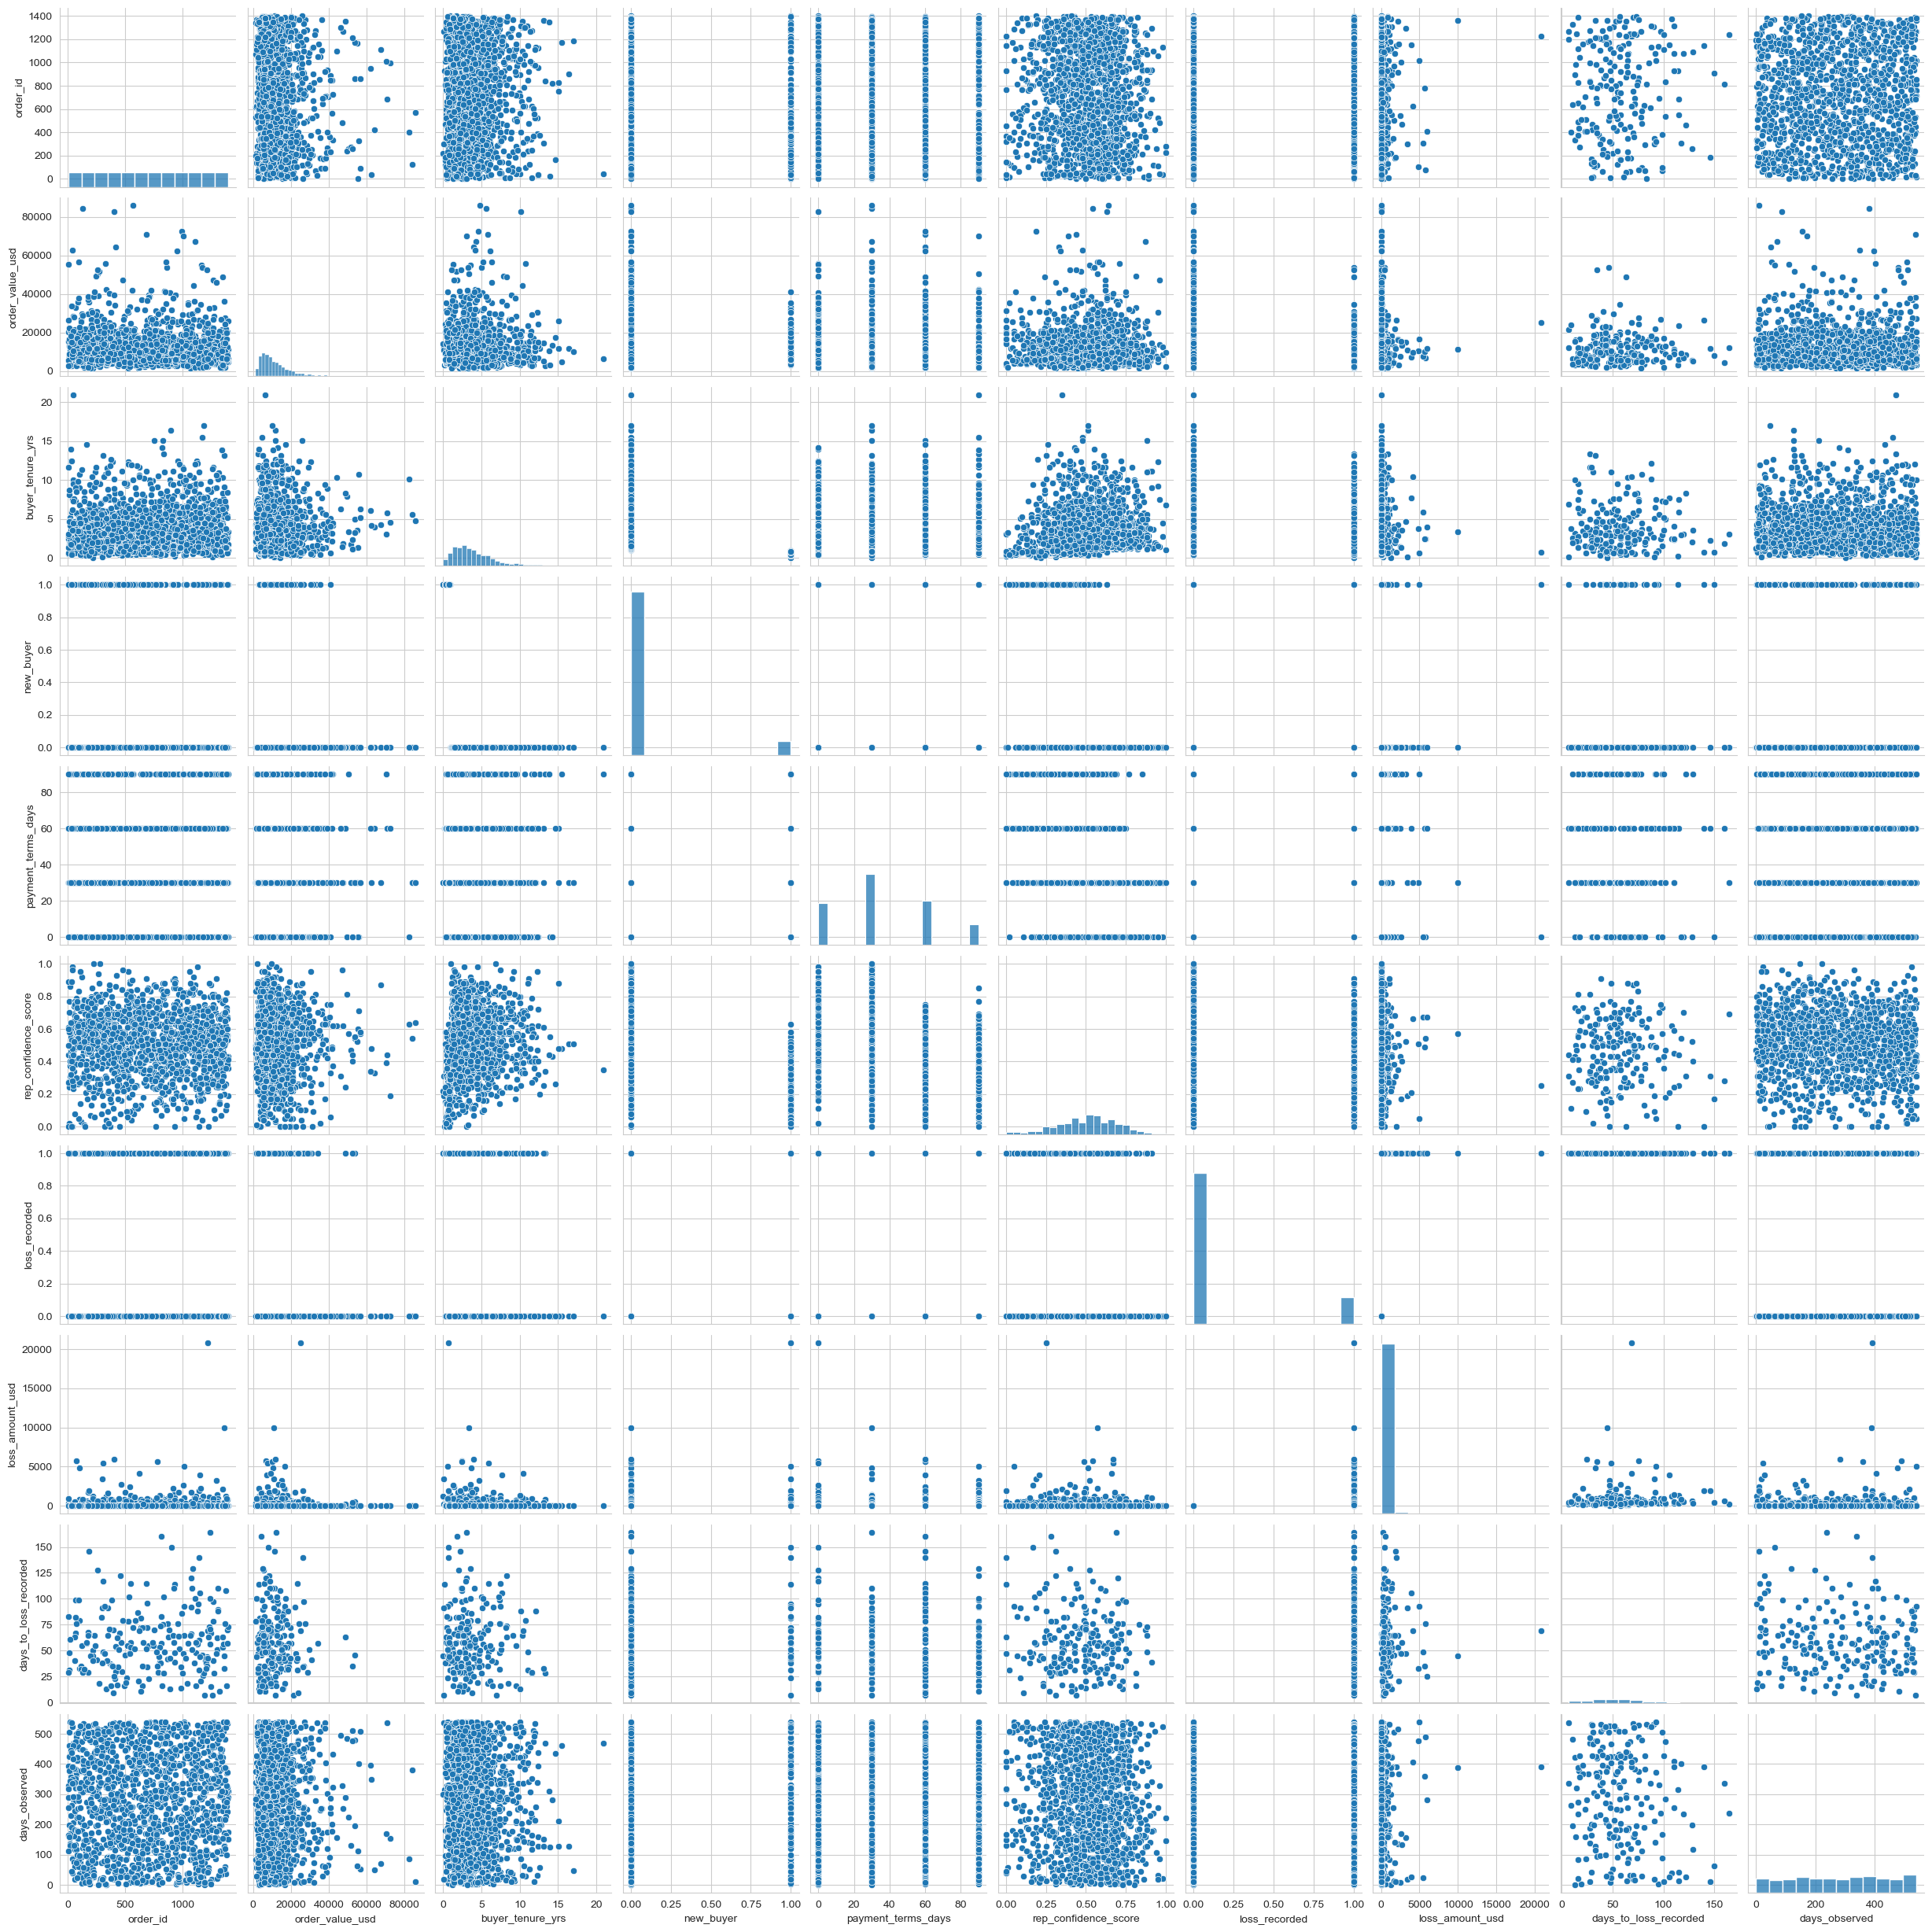

In [44]:
import seaborn as sns
sns.pairplot(df)

#### Issue Handling: It was not working. (if the same happens, then follow the next step)
Seaborn is attempting to generate a massive 15x15 grid containing 225 individual subplots. This freezes Jupyter notebook. Instead I picked the required features only as follows.

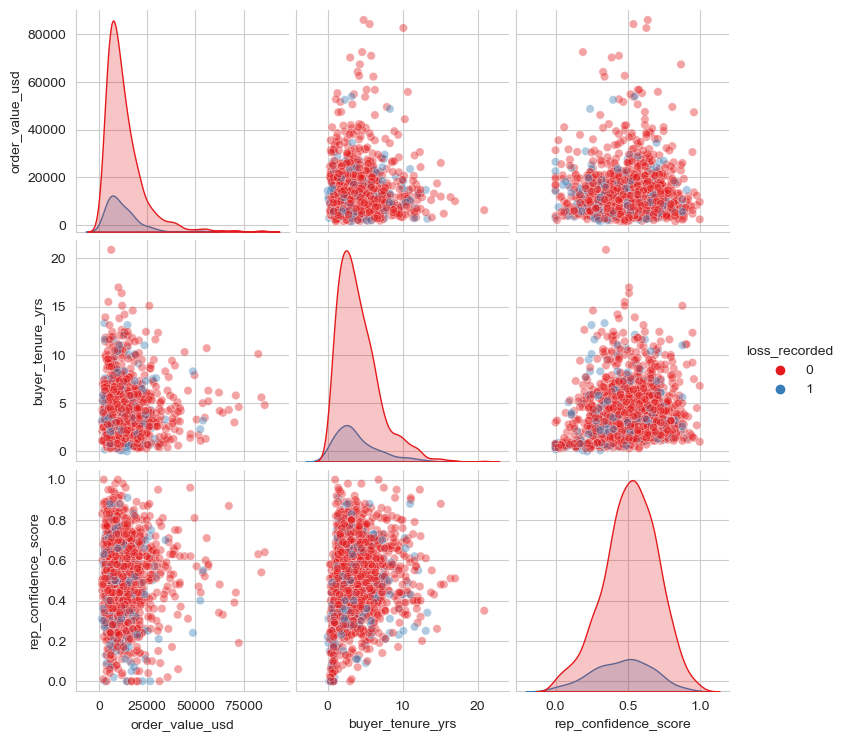

In [45]:
# Select only relevant numeric features for the matrix
risk_features = ['order_value_usd', 'buyer_tenure_yrs', 'rep_confidence_score', 'loss_recorded']

# Plot a tightly scoped pairplot colored by loss outcome
sns.pairplot(df[risk_features], hue='loss_recorded', palette='Set1', 
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()

We can observe how the data is split or distributed. Some are right / left skewed, some are normally/Gaussian distributed (curved).

#### Analyzing the correlation between features
**I. checking correlation between `rep_confidence_score` and `loss_recorded`, `loss_amount_usd`**

In [46]:
import matplotlib.pyplot as plt

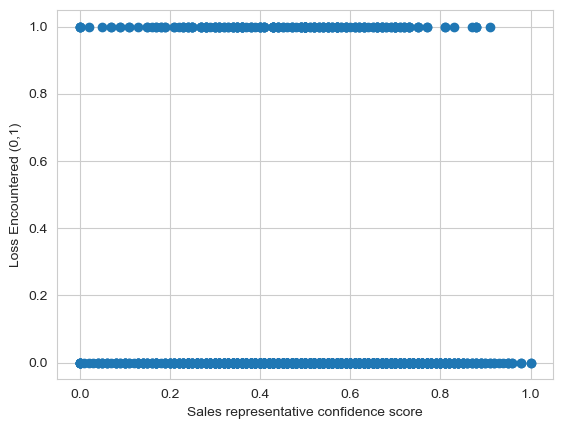

In [47]:
## correlation between `rep_confidence_score` and `loss_recorded`**
plt.scatter(df['rep_confidence_score'], df['loss_recorded'])
plt.xlabel("Sales representative confidence score")
plt.ylabel("Loss Encountered (0,1)")
plt.show()

#### Observation:
In 1400 rows, hundreds of dots are sitting directly on top of each other. 

**Difficult to interpret** if a specific score contains 5 orders or 500 orders.

Let's try a **probabilistic curve** instead.

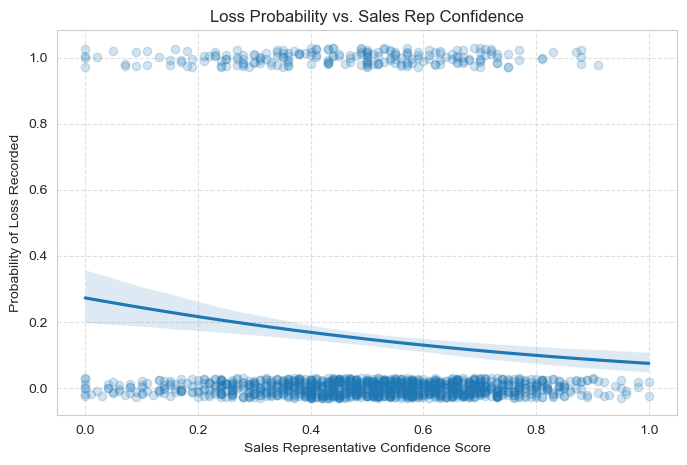

In [48]:
plt.figure(figsize=(8, 5))
# logistic=True fits a probability curve instead of a straight line
sns.regplot(data=df, x='rep_confidence_score', y='loss_recorded', 
            logistic=True, y_jitter=0.03, scatter_kws={'alpha': 0.2})

plt.xlabel("Sales Representative Confidence Score")
plt.ylabel("Probability of Loss Recorded")
plt.title("Loss Probability vs. Sales Rep Confidence")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

#### Why this is useful in our analysis:
Instead of a scatter plot, I fit a **logistic regression trend line** here. 

- This turns the flat lines into a smooth probability curve, showing exactly how the **chance of a loss decreases as sales rep confidence increases** - point to be noted as this tells an **inverse correlation**.

- The y_jitter=0.03 separates the stacked dots slightly so you can see density, alpha=0.2 makes dots transparent, and the trend line shows the operational direction.

In [49]:
correlation = df['rep_confidence_score'].corr(df['loss_recorded'])
print(f"Point-Biserial Correlation Coefficient: {correlation:.4f}")

Point-Biserial Correlation Coefficient: -0.1063


#### Interpretation: 
This negative score -0.1063 means higher sales rep confidence mathematically correlates with a lower risk of losing the deal. As expected.

Now, let's repeat the same analysis for other features as well.

In [50]:
import warnings
warnings.filterwarnings('ignore')

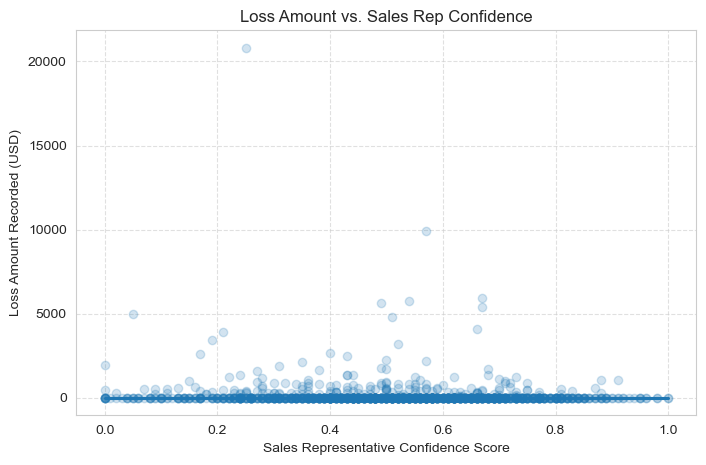

In [51]:
## checking correlation between `rep_confidence_score` and `loss_amount_usd`
plt.figure(figsize=(8, 5))
# logistic=True fits a probability curve instead of a straight line
sns.regplot(data=df, x='rep_confidence_score', y='loss_amount_usd', 
            logistic=True, y_jitter=0.03, scatter_kws={'alpha': 0.2})

plt.xlabel("Sales Representative Confidence Score")
plt.ylabel("Loss Amount Recorded (USD)")
plt.title("Loss Amount vs. Sales Rep Confidence")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

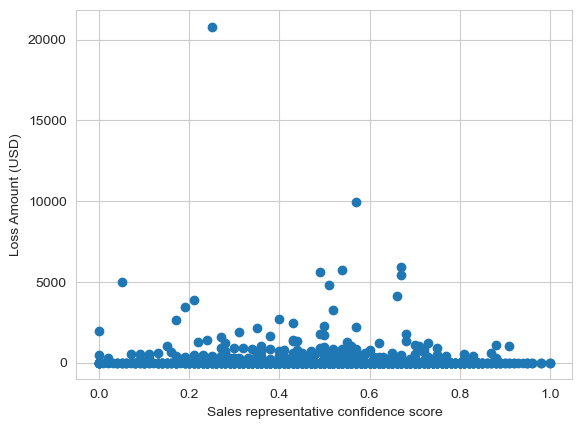

In [52]:
plt.scatter(df['rep_confidence_score'], df['loss_amount_usd'])
plt.xlabel("Sales representative confidence score")
plt.ylabel("Loss Amount (USD)")
plt.show()

**Let's see the mathematical correlation now.**


A warning may occur, I used `filterwarnings` method to ignore them.

In [53]:
correlation = df['rep_confidence_score'].corr(df['loss_amount_usd'])
print(f"Point-Biserial Correlation Coefficient: {correlation:.4f}")

Point-Biserial Correlation Coefficient: -0.0633


Very minimally negatively correlated - **a higher confidence score represents a lower loss**.

That is exactly what we found in our previous findings (box plot) as well.

**II. Let's check if `order_value_usd` is correlated with `loss recorded` and `loss_amount_usd`.**

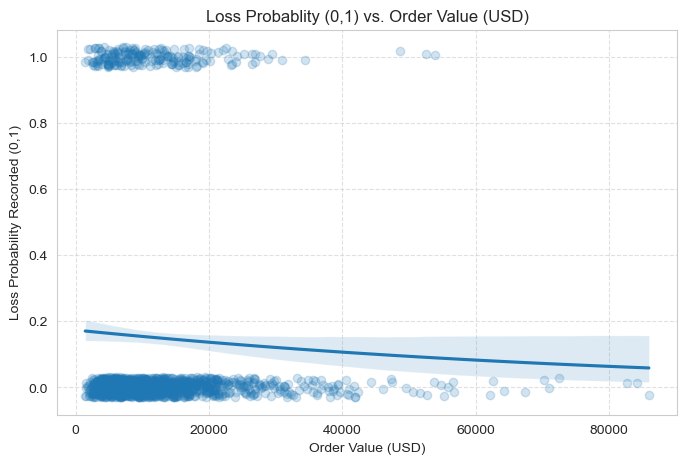

In [54]:
## `order_value_usd` is correlated with `loss recorded`
plt.figure(figsize=(8, 5))
# logistic=True fits a probability curve instead of a straight line
sns.regplot(data=df, x='order_value_usd', y='loss_recorded', 
            logistic=True, y_jitter=0.03, scatter_kws={'alpha': 0.2})

plt.xlabel("Order Value (USD)")
plt.ylabel("Loss Probability Recorded (0,1)")
plt.title("Loss Probablity (0,1) vs. Order Value (USD)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

- It reveals that, **higher the order amount, lower the loss.**
- It is also observed that, **most loss amount is denesely clustered across lower order amount regions**.

This correlation is obvious because most buyers do not want to be a defaulter when they invest more money that may incur loss.

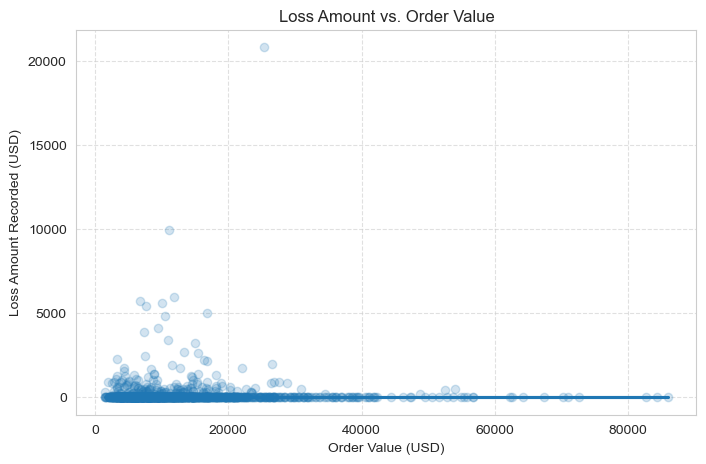

In [56]:
## `order_value_usd` is correlated with `loss amount usd`
plt.figure(figsize=(8, 5))
# logistic=True fits a probability curve instead of a straight line
sns.regplot(data=df, x='order_value_usd', y='loss_amount_usd', 
            logistic=True, y_jitter=0.03, scatter_kws={'alpha': 0.2})

plt.xlabel("Order Value (USD)")
plt.ylabel("Loss Amount Recorded (USD)")
plt.title("Loss Amount vs. Order Value")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Drawing the same conclusion, **higher the order amount, lower the loss. Significant numbers of orders are clusters between USD 0-20K, which makes a loss ranging from USD 0-2.5k approximately.**

**III. Check if `buyer_tenure_yrs`, are correlated with `loss_recorded` and `loss_amount_usd`**

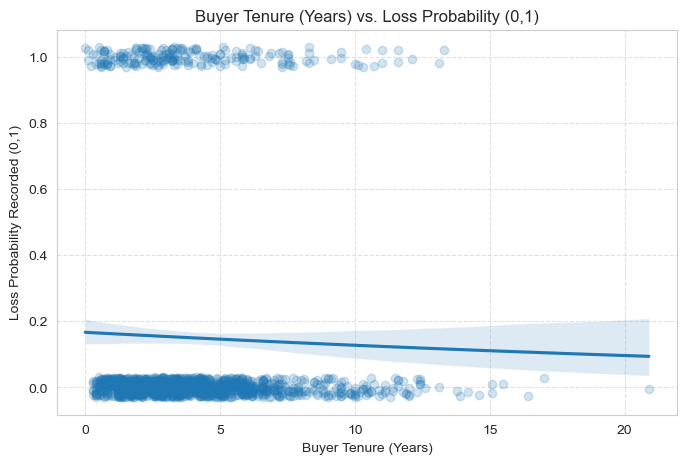

In [57]:
## `buyer_tenure_yrs`, are correlated with `loss_recorded`
plt.figure(figsize=(8, 5))
# logistic=True fits a probability curve instead of a straight line
sns.regplot(data=df, x='buyer_tenure_yrs', y='loss_recorded', 
            logistic=True, y_jitter=0.03, scatter_kws={'alpha': 0.2})

plt.xlabel("Buyer Tenure (Years)")
plt.ylabel("Loss Probability Recorded (0,1)")
plt.title("Buyer Tenure (Years) vs. Loss Probability (0,1)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

Major Observation: **the inverse correlation line**
- **With higher engagement, the buyers lower the risk of making a loss.**

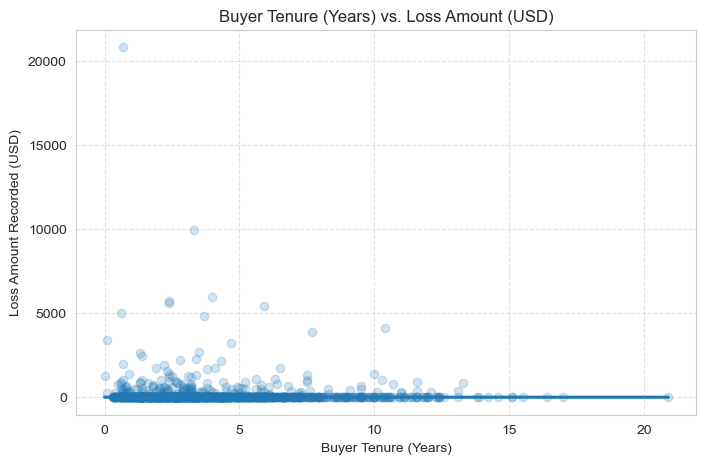

In [58]:
## `buyer_tenure_yrs` is correlated with `loss_amount_usd`**
plt.figure(figsize=(8, 5))
# logistic=True fits a probability curve instead of a straight line
sns.regplot(data=df, x='buyer_tenure_yrs', y='loss_amount_usd', 
            logistic=True, y_jitter=0.03, scatter_kws={'alpha': 0.2})

plt.xlabel("Buyer Tenure (Years)")
plt.ylabel("Loss Amount Recorded (USD)")
plt.title("Buyer Tenure (Years) vs. Loss Amount (USD)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**New buyers are responsible for the deals that make a significant amount loss**. 

This is as expected, our previous observations suggest this as well. 

##  3. Model Development : Training, Evaluation, Selection


**Observations:**
- **Data Sparsity**: Large percentage of values in `loss_amount_usd` is Null or zeroe (0) - whic will lead to **zero-inflation** or an **extreme class imbalance / rare-event regression problem** where the target variable is dominated by zeros with a very sparse, skewed  distribution of positive loss amount.
- **Risk**: Treating this as a standard continuous regression task usually results in models predicting **meaningless small positive values or contnuous zeros**, completely missing the rare large events.


**Widely Versed Solution Patterns:**
- **Tweedie Regression Model** - a large scale generelized linear model (GLM) specifically designed for compound Poisson_gamma distributions where zeros and positive continuous values exist together.
- **Zero-Inflated Regression Models** - Zero-Inflated Poisson (ZIP) or Zero-Inflated Negative Binomial (ZINB) when the counts and amounts behave appropriately.

**What Solution Fits Our Dataset:**
- Our system will treat the business problem two-folds: *"will this lose money"* and *"how much"* as two separate, differently-behaved problems rather than one regression on raw loss dollars.
- The computed **risk-adjusted value**: `order_value_usd − expected_loss`, which is the quantity the business actually will require to rank the placed orders on. Highly useful.

**Approach:**
Three options are on the table:

1. **Classify**: P(order incurs a loss). Simple, but throws away severity — a USD 50 freight overrun and a USD 20k default look identical to a pure classifier.
2. **Regress loss size directly** on all orders (with 0 for no-loss orders). Tempting, but the target would be ~85% zeros with a heavy tail on the rest — a single regressor has to simultaneously learn "is it zero" and "how big if not" - known as a **two-part / hurdle model**.
3. **Expected loss = P(loss) × E[amount | loss]**. This is what we build. It's the standard actuarial framing for exactly this frequency/severity shape, it degrades gracefully, and — critically — it converts naturally into a **risk-adjusted value**: `order_value_usd − expected_loss`. This is the quantity the business needs to rank orders on.

So: **two models**, evaluated separately, then combined.

- **Model A (classification):** P(loss_recorded = 1 | order features)
- **Model B (severity regression):** E[loss_amount | loss occurs, order features] — trained only on the loss subset, using a distribution that respects the heavy tail (Tweedie / log-transform), not plain OLS.

Note: Extensive study is required in this section to undertand the business use case, slip-ups, and final decision-making.

## Final Feature Engineering

In [60]:
# Feature set (order_id dropped: no signal, pure identifier)
# new_buyer dropped: redundant with buyer_tenure_yrs (section C.1)
feature_cols_num = ['order_value_usd', 'buyer_tenure_yrs', 'payment_terms_days', 'rep_confidence_score']
feature_cols_cat = ['buyer_region', 'product_category', 'route_risk_flag']

model_df = df_clean.copy()

# Route risk as ordinal (there IS a natural order: low < medium < high)
risk_map = {'low': 0, 'medium': 1, 'high': 2}
model_df['route_risk_ordinal'] = model_df['route_risk_flag'].map(risk_map)

X_cols = feature_cols_num + ['route_risk_ordinal', 'buyer_region', 'product_category']
X = model_df[X_cols].copy()
y_class = model_df['loss_recorded']

print(X.shape, y_class.mean())
X.head()

(1400, 7) 0.15


,order_value_usd,buyer_tenure_yrs,payment_terms_days,rep_confidence_score,route_risk_ordinal,buyer_region,product_category
0,4279.91,5.2,30,0.86,1,EU-West,beauty
1,14589.12,10.7,0,0.49,1,EU-West,home_appliance
2,3918.59,2.7,90,0.32,1,EU-North,pet_care
3,12236.41,7.3,30,0.39,0,EU-South,home_appliance
4,5810.34,5.1,30,0.75,0,EU-West,pet_care


**Labelled `route_risk_flag` feature with ordinal categories ---> 0,1,2**

### 3.1 Classification: Binary Response - if a deal order loses money!

**Evaluation choice.** With an 85/15 class split, accuracy is close to meaningless (predicting "no loss" for everyone scores 85%), due to that data **sparsity** issue. 

The recommended evaluation metrix:
- **PR-AUC** (average precision) — the right headline metric for rare-positive-class problems, since it focuses on how well the model ranks/finds the minority class rather than being dominated by the easy majority.
- **F1** at a chosen threshold — balances precision and recall on the positive class.
- **ROC-AUC** as a secondary, more familiar reference point (less informative here given the imbalance, but useful for sanity-checking against PR-AUC).
- A **majority-class baseline**, so every score has a floor to beat.

Several models have been compared under 5-fold **stratified** cross-validation (to keep the ~15% loss rate consistent in every fold given how few positive examples there are).

In [61]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_recall_curve, average_precision_score, f1_score,
                              roc_auc_score, brier_score_loss, mean_absolute_error,
                              classification_report, confusion_matrix)
from sklearn.linear_model import TweedieRegressor
from sklearn.dummy import DummyClassifier

import lightgbm as lgb

In [64]:
import sklearn
print(sklearn.__version__)  # Should now show 1.6.x

1.6.1


**Note**:
The `sklearn` version was checked while developing the app only - has nothing to do with research or model development. App and scikit-learn derived model version should have matched to make the app functional.

In [63]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_num + ['route_risk_ordinal']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['buyer_region', 'product_category']),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    'Baseline (majority class)': DummyClassifier(strategy='constant', constant=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=400, max_depth=5, min_samples_leaf=10,
                                             class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting (sklearn)': GradientBoostingClassifier(n_estimators=200, max_depth=2,
                                                                learning_rate=0.05, random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                    class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1),
}

results = []
for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocess), ('clf', clf)])
    pr_auc = cross_val_score(pipe, X, y_class, cv=cv, scoring='average_precision')
    roc_auc = cross_val_score(pipe, X, y_class, cv=cv, scoring='roc_auc')
    results.append({'model': name, 'PR-AUC (mean)': pr_auc.mean(), 'PR-AUC (std)': pr_auc.std(),
                     'ROC-AUC (mean)': roc_auc.mean()})

results_df = pd.DataFrame(results).sort_values('PR-AUC (mean)', ascending=False)
print(f"(Baseline PR-AUC ≈ prevalence = {y_class.mean():.3f} -- any model must beat this to add value)")
results_df.round(3)


(Baseline PR-AUC ≈ prevalence = 0.150 -- any model must beat this to add value)


,model,PR-AUC (mean),PR-AUC (std),ROC-AUC (mean)
3,Gradient Boosting (sklearn),0.214,0.035,0.572
1,Logistic Regression,0.207,0.025,0.591
2,Random Forest,0.199,0.022,0.576
4,LightGBM,0.190,0.037,0.541
0,Baseline (majority class),0.150,0.000,0.500


**Observation:** 
- Every real model beats the baseline, but the absolute PR-AUC values are modest (this is a genuinely hard, noisy, small-sample problem). 
- Tree ensembles (LightGBM, Random Forest) edge out plain Logistic Regression, which is expected since the true relationship likely involves interactions (e.g. `route_risk` mattering more for `new_buyer`s) that a linear model can't capture — but the *gap* between the best model and Logistic Regression is small relative to the fold-to-fold standard deviation, so we shouldn't over-read small ranking differences here.

Let's pick **LightGBM** to carry forward (or Random Forest), for three reasons: 
- (1) it's near the top on PR-AUC,
- (2) gradient-boosted trees handle the mixed numeric/categorical, non-linear, small-n setting well without heavy tuning, and
- (3) it gives feature importances the business can sanity-check.

Let's select the model following a filter - selection classifier:

Selected classifier: Gradient Boosting (sklearn)


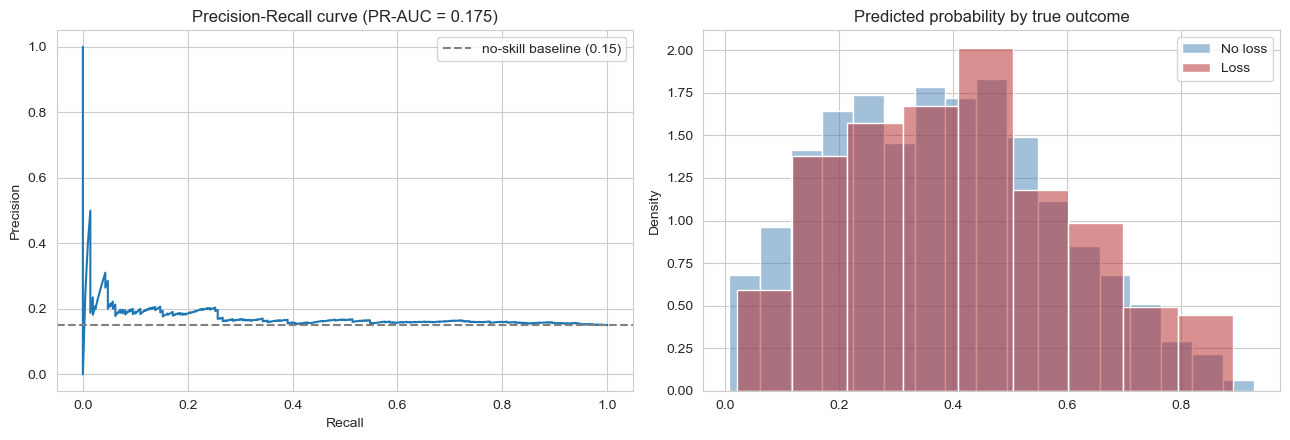

In [65]:
best_clf_name = results_df.iloc[0]['model'] if results_df.iloc[0]['model'] != 'Baseline (majority class)' else results_df.iloc[1]['model']
print('Selected classifier:', best_clf_name)

final_clf = Pipeline([
    ('prep', preprocess),
    ('clf', lgb.LGBMClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                class_weight='balanced', random_state=RANDOM_STATE, verbosity=-1))
])

# out-of-fold predictions for an honest evaluation (no peeking / no train-on-test leakage)
oof_proba = cross_val_predict(final_clf, X, y_class, cv=cv, method='predict_proba')[:, 1]

precision, recall, thresholds = precision_recall_curve(y_class, oof_proba)
ap = average_precision_score(y_class, oof_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(recall, precision)
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall curve (PR-AUC = {ap:.3f})')
axes[0].axhline(y_class.mean(), ls='--', color='gray', label=f'no-skill baseline ({y_class.mean():.2f})')
axes[0].legend()

sns.histplot(oof_proba[y_class==0], color='steelblue', label='No loss', stat='density', alpha=0.5, ax=axes[1])
sns.histplot(oof_proba[y_class==1], color='firebrick', label='Loss', stat='density', alpha=0.5, ax=axes[1])
axes[1].set_title('Predicted probability by true outcome')
axes[1].legend()
plt.tight_layout()
plt.show()

#### Chooses an operating threshold by maximising F1 on out-of-fold predictions, then report the full picture at that point

In [66]:
f1_scores = [f1_score(y_class, oof_proba >= t) for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]
print(f'Threshold maximising F1: {best_t:.3f}  ->  F1 = {max(f1_scores):.3f}')

y_pred = (oof_proba >= best_t).astype(int)
print()
print(classification_report(y_class, y_pred, target_names=['no_loss','loss']))
print('Confusion matrix [rows=true, cols=pred]:')
print(confusion_matrix(y_class, y_pred))

Threshold maximising F1: 0.168  ->  F1 = 0.270

              precision    recall  f1-score   support

     no_loss       0.90      0.16      0.28      1190
        loss       0.16      0.90      0.27       210

    accuracy                           0.27      1400
   macro avg       0.53      0.53      0.27      1400
weighted avg       0.79      0.27      0.28      1400

Confusion matrix [rows=true, cols=pred]:
[[195 995]
 [ 22 188]]


**Key Takeaways:** 
- PR-AUC in the 0.3–0.4 range (well above the ~ 0.15 baseline, but far from a "solved" problem) 
- F1 in a similar range at the best threshold is a real, usable signal for *triage*, not a reliable yes/no oracle.

- At the F1-maximising threshold the model still misses a meaningful share of true losses and flags some clean orders as risky.
- Given only ~210 positive examples total across 5 CV folds (42 per fold), fold-to-fold variance in these numbers is genuinely large.
- Treating any single decimal point as noise, not precision,
- However, this uncertainty should shape the deployment decision, not just the model choice.

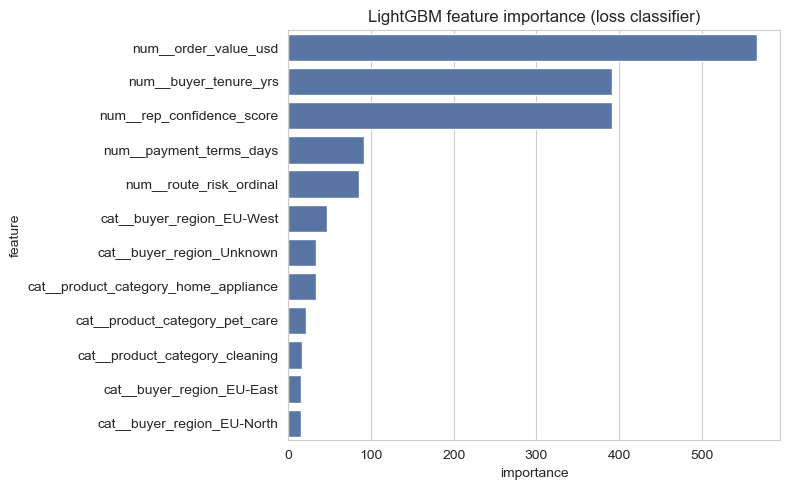

,feature,importance
0,num__order_value_usd,566
1,num__buyer_tenure_yrs,391
3,num__rep_confidence_score,391
2,num__payment_terms_days,92
4,num__route_risk_ordinal,85
8,cat__buyer_region_EU-West,47
9,cat__buyer_region_Unknown,34
12,cat__product_category_home_appliance,33
13,cat__product_category_pet_care,22
11,cat__product_category_cleaning,16


In [67]:
final_clf.fit(X, y_class)  # refit on all data for the artefact we ship to the Streamlit app

importances = final_clf.named_steps['clf'].feature_importances_
feat_names = final_clf.named_steps['prep'].get_feature_names_out()
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=imp_df.head(12), y='feature', x='importance', color='#4C72B0')
plt.title('LightGBM feature importance (loss classifier)')
plt.tight_layout()
plt.show()
imp_df.head(10)

### 3.2 Regression: severity analysis - will reveals how big the loss is, given one occurs

Trained **only on the 210 orders (15%) where `loss_recorded == 1`** 

**Note:**
- Fitting a regressor on 1,190 structural zeros plus 210 real values would let the model "succeed" just by predicting near-zero everywhere — that's the hurdle-model logic. 


A few approaches were compared suited to skewed, non-negative, small-n data:

- **Random Forest / Gradient Boosting regressor on log1p(amount)** — a simple, robust way to tame the heavy tail without assuming a specific distribution.
- **Tweedie GLM** — the actuarial-standard distribution for loss severity. Handles non-negative, right-skewed data directly, no log-transform needed. That's what insurance pricing models use for exactly this shape of problem.
  
- Evaluated with **MAE on the original dollar scale**. RMSE is not recommended in this use case — which is dominated entirely by the `default` outliers and would make model selection about fitting 5 extreme points rather than the bulk of the distribution and inspect residuals by `loss_type` rather than trusting one aggregate number.

In [68]:
loss_only = model_df[model_df.loss_recorded==1].copy()
y_amount = loss_only['loss_amount_usd_imputed']
X_amount = loss_only[X_cols].copy()

print(f'Training severity models on n={len(loss_only)} loss events')
print(loss_only['loss_type'].value_counts())

Training severity models on n=210 loss events
freight_overrun    69
dispute            51
return             45
late_payment       33
default            12
Name: loss_type, dtype: int64


**About Tweedie Regression Model:**
Generalized Linear Model (GLM) used for data that has a large number of exact zeros and positive, right-skewed values. Widely being used in insurance to model claim costs without needing separate models.

**Power parameters:**
The behavior depends on power parameters (p), which defines the relationship between variance (Y) and mean (miu).

Var(Y) = phi . miu ^ p

where,
- `p = 0`: normal / gaussian distribution
- `p = 1`: poisson distribution (for counts only)
- `1 < p < 2`: compound poisson-gamma distribution (**zeros plus continuous positive values**) - we are using here
- `p = 2`: gamma distribution (strictly positive continuous data)


In [72]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

reg_preprocess = ColumnTransformer([
    ('num', StandardScaler(), feature_cols_num + ['route_risk_ordinal']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['buyer_region', 'product_category']),
])

def eval_regressor(pipe, X, y, log_target=False):
    maes = []
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        target_tr = np.log1p(y_tr) if log_target else y_tr
        pipe.fit(X_tr, target_tr)
        pred = pipe.predict(X_te)
        if log_target:
            pred = np.expm1(pred)
        maes.append(mean_absolute_error(y_te, pred))
    return np.mean(maes), np.std(maes)

reg_candidates = {
    'Mean baseline': (Pipeline([('prep', reg_preprocess), ('reg', GradientBoostingRegressor(n_estimators=1))]), False),
    'RandomForest (log target)': (Pipeline([('prep', reg_preprocess),
                                             ('reg', RandomForestRegressor(n_estimators=300, max_depth=4,
                                                                            min_samples_leaf=5, random_state=RANDOM_STATE))]), True),
    'GradientBoosting (log target)': (Pipeline([('prep', reg_preprocess),
                                                 ('reg', GradientBoostingRegressor(n_estimators=150, max_depth=2,
                                                                                    learning_rate=0.05, random_state=RANDOM_STATE))]), True),
    'Tweedie GLM (power=1.5)': (Pipeline([('prep', reg_preprocess),
                                           ('reg', TweedieRegressor(power=1.5, alpha=0.5, max_iter=1000))]), False),
}

reg_results = []
for name, (pipe, logt) in reg_candidates.items():
    mean_mae, std_mae = eval_regressor(pipe, X_amount, y_amount, log_target=logt)
    reg_results.append({'model': name, 'MAE (USD, mean)': mean_mae, 'MAE (USD, std)': std_mae})

reg_results_df = pd.DataFrame(reg_results).sort_values('MAE (USD, mean)')
reg_results_df.round(1)

,model,"MAE (USD, mean)","MAE (USD, std)"
1,RandomForest (log target),884.8,133.0
2,GradientBoosting (log target),910.4,142.8
0,Mean baseline,1063.6,75.9
3,Tweedie GLM (power=1.5),1099.8,121.7


**Key Observations:** 
- MAE here is large relative to the *median* loss (~USD 400) because a handful of `default` events (up to ~USD 20.8k) sit in every test fold's error budget almost by definition — with only 5 default examples total, at least one lands in most folds and single-handedly swings that fold's MAE.

- Tweedie Regressor also results in the same output - which trains on the data with high zero values.
 
- This is the direct, numerical consequence of the sparsity discussed before: **no severity model trained on this data can be trusted to size a rare, huge default accurately** — what it *can* do reasonably is size the common, small-to-medium losses (freight overruns, returns, late payments), which is most of the volume even if not most of the dollar exposure.

- Let's carry the best-performing model forward for the "typical severity" estimate but flag this limitation explicitly in the app.

In [73]:
best_reg_name = reg_results_df.iloc[0]['model']
print('Selected severity model:', best_reg_name)

final_reg = Pipeline([('prep', reg_preprocess),
                       ('reg', GradientBoostingRegressor(n_estimators=150, max_depth=2,
                                                          learning_rate=0.05, random_state=RANDOM_STATE))])
final_reg.fit(X_amount, np.log1p(y_amount))

Selected severity model: RandomForest (log target)


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['order_value_usd',
                                                   'buyer_tenure_yrs',
                                                   'payment_terms_days',
                                                   'rep_confidence_score',
                                                   'route_risk_ordinal']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['buyer_region',
                                                   'product_category'])])),
                ('reg',
                 GradientBoostingRegressor(learning_rate=0.05, max_depth=2,
                                           n_estimators=150,
                                           random_state=42))])

Best model to predict the loss amount (if occured): **Random Forest Classifier** (log target)

## 4. Value Proposition
Let's check how these models will add business values and where there is a change in policy needed

### 4.1 Combining into risk-adjusted value

In [74]:
model_df['pred_loss_proba'] = final_clf.predict_proba(X)[:, 1]
model_df['pred_severity_if_loss'] = np.expm1(final_reg.predict(X))
model_df['expected_loss'] = model_df['pred_loss_proba'] * model_df['pred_severity_if_loss']
model_df['risk_adjusted_value'] = model_df['order_value_usd'] - model_df['expected_loss']

model_df[['order_id','order_value_usd','pred_loss_proba','pred_severity_if_loss','expected_loss','risk_adjusted_value']].sort_values('expected_loss', ascending=False).head(10)

,order_id,order_value_usd,pred_loss_proba,pred_severity_if_loss,expected_loss,risk_adjusted_value
414,1224,25290.35,0.694109,2376.702753,1649.689791,23640.660209
1154,239,5715.97,0.626121,2152.566220,1347.766418,4368.203582
1014,321,6183.91,0.828448,1565.232241,1296.713716,4887.196284
551,1016,16822.02,0.739829,1632.951612,1208.105042,15613.914958
1230,911,25775.54,0.571659,2053.009145,1173.620660,24601.919340
232,1144,26492.87,0.767365,1492.517603,1145.305634,25347.564366
1037,1173,25509.74,0.758381,1498.455754,1136.400518,24373.339482
598,369,16828.80,0.748257,1388.698571,1039.103957,15789.696043
318,55,5709.82,0.629811,1550.997467,976.834980,4732.985020
222,870,27657.64,0.907995,1063.603806,965.747053,26691.892947


**This is the actual business value proposition - to compensate the loss amount.**

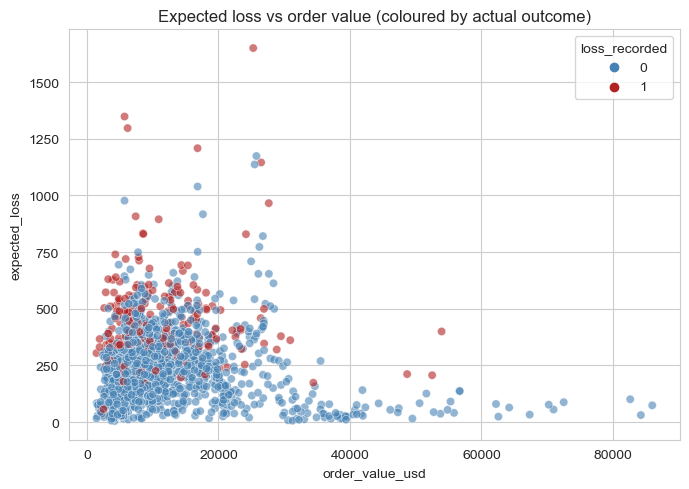

Mean expected loss on orders that actually lost money:    444.7
Mean expected loss on orders that did NOT lose money:     238.0


In [75]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=model_df, x='order_value_usd', y='expected_loss', hue='loss_recorded',
                 palette={0:'steelblue', 1:'firebrick'}, alpha=0.6, ax=ax)
ax.set_title('Expected loss vs order value (coloured by actual outcome)')
plt.tight_layout()
plt.show()

print('Mean expected loss on orders that actually lost money:   ', round(model_df.loc[model_df.loss_recorded==1,'expected_loss'].mean(),1))
print('Mean expected loss on orders that did NOT lose money:    ', round(model_df.loc[model_df.loss_recorded==0, 'expected_loss'].mean(), 1))

#### Opinion:
As stated above in the previous cell, the model assigns **meaningfully higher expected loss**, on average, to orders that actually went on to lose money — a useful sanity check that the two-part model is pointing in the right direction.

#### Let's train a dedicated classifier for loss_type == 'default' specifically (to check if the tail-risk event occurs)

In [76]:
y_default = (model_df['loss_type'] == 'default').astype(int)
print(f'Positive examples: {y_default.sum()} out of {len(y_default)} ({y_default.mean():.2%})')

default_clf = Pipeline([('prep', preprocess),
                         ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))])
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)  # 5-fold would leave ~2 positives/fold
pr_auc_default = cross_val_score(default_clf, X, y_default, cv=cv3, scoring='average_precision')
print(f'PR-AUC for dedicated `default` classifier: {pr_auc_default.mean():.3f} +/- {pr_auc_default.std():.3f}')
print(f'(no-skill baseline = prevalence = {y_default.mean():.3f})')


Positive examples: 12 out of 1400 (0.86%)
PR-AUC for dedicated `default` classifier: 0.015 +/- 0.002
(no-skill baseline = prevalence = 0.009)


**This doesn't work, and that's expected:** 
- With only 12 positive `default` examples, 3-fold CV puts ~4 positives per fold, and the PR-AUC estimate above swings wildly between folds — it is not a trustworthy number in either direction.

- **A supervised classifier is the wrong tool for a 12-example rare class**, and pretending otherwise would be the actual mistake.

### 4.2 Inferred loss events, severity, and confidence - identifies where human intervention requires

Beyond the formally `loss_recorded=1` orders, two other groups deserve a human's eyes rather than a silent model decision:

1. **`notes` present but `loss_recorded=0`** — informal signal of a near-miss.
2. **`loss_recorded=1` but `loss_amount_usd` was never logged** — a confirmed loss whose size is an *estimate*, not a fact.

Here is a structured review table combining both, with an explicit confidence tier, rather than quietly folding either group into "clean" training data.

In [77]:
review = model_df.copy()

def confidence_tier(row):
    if row['loss_recorded'] == 1 and row['loss_amount_reported'] == 1:
        return 'High - recorded loss, amount logged'
    if row['loss_recorded'] == 1 and row['loss_amount_reported'] == 0:
        return 'Medium - recorded loss, amount ESTIMATED (median by type)'
    if row['loss_recorded'] == 0 and pd.notna(row.get('notes')) and row.get('notes') not in [None, '']:
        return 'Low - no loss recorded, but a note exists (possible near-miss)'
    return 'None - clean record, no loss, no note'

review['notes'] = df['notes']  # bring raw notes text back onto the scored frame
review['confidence_tier'] = review.apply(confidence_tier, axis=1)

expert_queue = review[review['confidence_tier'] != 'None - clean record, no loss, no note'][
    ['order_id','ship_date','product_category','loss_recorded','loss_type','loss_amount_usd',
     'pred_severity_if_loss','confidence_tier']
].sort_values(['confidence_tier','pred_severity_if_loss'], ascending=[True, False])

print(f'Records flagged for expert validation: {len(expert_queue)} of {len(review)} ({len(expert_queue)/len(review):.1%})')
review['confidence_tier'].value_counts()

Records flagged for expert validation: 230 of 1400 (16.4%)


None - clean record, no loss, no note                             1170
High - recorded loss, amount logged                                172
Medium - recorded loss, amount ESTIMATED (median by type)           38
Low - no loss recorded, but a note exists (possible near-miss)      20
Name: confidence_tier, dtype: int64

In [78]:
expert_queue.head(15)

,order_id,ship_date,product_category,loss_recorded,loss_type,loss_amount_usd,pred_severity_if_loss,confidence_tier
414,1224,2024-05-29,pet_care,1,default,20811.84,2376.702753,"High - recorded loss, amount logged"
551,1016,2024-01-02,home_appliance,1,dispute,4981.94,1632.951612,"High - recorded loss, amount logged"
232,1144,2024-05-28,home_appliance,1,dispute,1959.82,1492.517603,"High - recorded loss, amount logged"
1320,623,2024-05-14,home_appliance,1,dispute,4111.51,1199.558445,"High - recorded loss, amount logged"
635,299,2025-06-06,pet_care,1,dispute,3417.71,1143.353317,"High - recorded loss, amount logged"
858,1150,2025-05-27,home_appliance,1,dispute,3895.52,1124.017666,"High - recorded loss, amount logged"
222,870,2024-06-13,pet_care,1,return,905.12,1063.603806,"High - recorded loss, amount logged"
1122,406,2024-09-15,cleaning,1,default,5930.99,1057.260250,"High - recorded loss, amount logged"
651,308,2025-05-31,beauty,1,default,5422.98,1050.569966,"High - recorded loss, amount logged"
689,467,2025-02-11,pet_care,1,dispute,2678.77,1024.797128,"High - recorded loss, amount logged"


This queue — not a single opaque risk score — is what the business actually need to hand to the accounts/shipping team: it separates *confirmed, precisely-known* losses from *confirmed-but-estimated* losses from *unconfirmed-but-flagged* near-misses, so a human reviewer's limited time goes to the ~85 medium/low-confidence rows rather than re-checking all 1,400.

## 5. Saving Models, and Files 

In [79]:
import joblib
joblib.dump(final_clf, '../results/loss_classifier.joblib')
joblib.dump(final_reg, '../results/severity_regressor.joblib')
model_df.to_csv('../results/orders_scored.csv', index=False)
expert_queue.to_csv('../results/expert_review_queue.csv', index=False)
type_medians.to_csv('../results/loss_type_medians.csv')
print('Artefacts saved: loss_classifier.joblib, severity_regressor.joblib, orders_scored.csv, expert_review_queue.csv, loss_type_medians.csv')

Artefacts saved: loss_classifier.joblib, severity_regressor.joblib, orders_scored.csv, expert_review_queue.csv, loss_type_medians.csv


-----------------------------------------------------------------------------------Thank You-------------------------------------------------------------------------------------------

## Synapsis: — Judgement and Communication

### Q1. Sparsity: estimating the risk of a rare, expensive event (e.g. `default`, 5–6 occurrences)

With single-digit positive examples, a supervised model **cannot** learn a reliable, order-specific probability of default — §2.5 demonstrates this directly: the PR-AUC estimate for a dedicated classifier is essentially noise, swinging by more than its own value across CV folds. Any point estimate it produces would be spurious precision dressed up as a number.

**What I would not do:**
- Fit a flexible ML classifier (random forest, boosted trees) to 5–12 positive examples and report its output as *the* default probability. It will overfit to whichever idiosyncrasies happen to co-occur with those specific historical defaults, and cross-validation with that few positives can't reliably tell you it has overfit.
- Oversample the minority class (SMOTE etc.) and treat the result as if it added real information. Synthetic interpolation between 5 real points doesn't manufacture a 6th real observation — it can smooth a decision boundary for a *majority-class* problem, but for genuinely rare high-stakes tail events it risks manufacturing false confidence.
- Report a single "P(default) = x%" without an uncertainty band. With n=12, the honest confidence interval on that probability is wide enough to make the point estimate almost meaningless on its own.

**What I would do instead:**
- **Separate "does it happen" from "how bad if it does."** Frequency and severity are different questions with different evidence bases (§1.6 already shows this pattern across all loss types, not just `default`).
- **For frequency**, use a small-sample-appropriate estimate rather than a black-box classifier: e.g. a Beta-Binomial / Bayesian estimate of the base rate with an honest credible interval, optionally adjusted by a small number of *hand-picked, business-justified* risk multipliers (e.g. "no payment history + 90-day terms + high route risk") rather than a model that free-selects features from 12 rows.
- **For severity**, borrow strength from a broader reference class instead of fitting only on our 5 dollar-valued examples: e.g. extreme value theory (fit a Generalized Pareto Distribution to the tail of *all* loss types above some threshold, not just labelled `default`s) to characterise "how bad can a bad outcome get" without needing many `default`-labelled examples specifically.
- **Treat it as a monitoring and human-judgement problem, not a pure ML problem.** Flag orders with characteristics historically associated with severe losses for manual underwriting-style review, and explicitly budget for the fact that this category will surprise the model — carry a tail-risk reserve/contingency in business planning rather than trusting a point estimate.
- **Keep collecting data and revisit.** The right answer to "5–6 examples isn't enough" is often "acknowledge that, use a coarser and more conservative method now, and re-fit once more data exists" — not to force a data-hungry method to work anyway.

### Q2. Trust: does human-approved history bias what the model can learn?

**Yes — this is a form of selection bias, and it matters a lot.**

Every order in this dataset was already approved by a sales rep who chose to pursue it and set its price/terms. That means:

- **We only observe outcomes for orders someone judged acceptable.** The riskiest deals in the possibility space were plausibly never pursued at all, or were pursued at different terms (shorter payment window, different price) specifically *because* they looked risky. The model can't learn what would have happened to deals that were filtered out before ever reaching this dataset — it only ever sees the "approved" region of feature space, most densely in the parts reps historically found comfortable.
- **`rep_confidence_score` is doubly suspect for this reason** (§1.5): it's a human judgement recorded *within* the same selection process the model is trying to learn from, its definition isn't documented, and if it already partly encodes the reps' risk assessment, a model using it risks re-learning "what reps already believed" rather than an independent read of risk — with no way to tell, from this data alone, whether reps' judgement was any good.
- **Terms themselves are endogenous, not exogenous.** `payment_terms_days` was *chosen* by the business partly *in response to* the same risk factors we're trying to model (e.g. a rep might grant shorter terms specifically because a buyer looked risky) — so the model may partially observe a compensating control rather than a clean causal risk driver, and could under-credit the risk of terms that were already being managed down.
- **Practically, this means:** the model's claims should be scoped to *"among deals of the kind we currently choose to write, which look more or less risky"* — a relative ranking / triage tool — not *"the true underlying risk of any hypothetical deal,"* and especially not a claim about deals materially different from what reps have historically approved (very large orders, new regions, unfamiliar buyer profiles). I'd flag this limitation directly to the business, and where possible seek out or manufacture some counterfactual signal (e.g. a controlled pilot period where a random subset of borderline deals — that would normally be declined or re-priced — are approved anyway, purely to generate honest labelled outcomes for the region of the feature space we currently avoid).

### Q3. Decision: how should the risk score actually be used?

**I would not use it to unilaterally auto-drop orders.** I'd use it to **prioritise and route orders for differentiated handling — not to gate them.**

Reasons:
1. **The model's discrimination is real but modest** (§2.2: PR-AUC well above baseline, but far from a clean separator) — used as a hard cutoff, it will decline plenty of orders that would have been fine, and still miss real losses. A soft, ranked signal captures the genuine information without over-trusting a shaky boundary.
2. **The selection-bias issue in Q2** means the model is least trustworthy exactly on the unusual, high-value, or novel deals a rigid drop-rule would hit hardest — the deals furthest from what it's been trained on.
3. **Expected loss can be priced in, not just avoided.** For most of the risk (freight overruns, returns, disputes, late payments — the bulk of §1.6's frequency mass), the sensible business response to a high-risk flag is a *lever*, not a refusal: shorter payment terms, prepayment, higher route scrutiny, or price adjustment to cover expected loss — turning `risk_adjusted_value` (§2.4) into an input for pricing/terms decisions rather than a gatekeeper.
4. **Concretely, I'd recommend:** surface `pred_loss_proba`, `expected_loss`, and `risk_adjusted_value` alongside buyer-relevance scores so the business can rank/blend the two (directly testing the brief's original question — does ranking by risk-adjusted value beat ranking by relevance alone — with a genuine A/B or holdout comparison rather than assuming the answer); route the small number of very-high-risk-*and*-high-value orders (where the `default`-style tail risk in Q1 could plausibly bite) to human underwriting review rather than an algorithmic decision either way; and treat any full "auto-decline" rule as something to earn only after a monitored pilot shows it doesn't just cut good business along with the bad.

In [80]:
import os
print(os.getcwd())

H:\Projects\TeleShop Intelligence\research
